# A. Model Training

In [69]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

warnings.filterwarnings("ignore")

### ----------------------------------------------------------------------------
### A.1 Load the curated dataset (produced by 01_ingest_clean.ipynb)
### ----------------------------------------------------------------------------

In [70]:
print("Loading curated dataset...")
df = pd.read_parquet("../data/curated/home_credit_curated.parquet")

print(f"Dataset shape: {df.shape}")
print(f"TARGET distribution:\n{df['TARGET'].value_counts(normalize=True).round(4)}")
print(f"Columns: {list(df.columns)}")

# ----------------------------------------------------------------------------
# Separate features and target
# ----------------------------------------------------------------------------
X = df.drop(columns=["TARGET"])
y = df["TARGET"]

Loading curated dataset...
Dataset shape: (250655, 176)
TARGET distribution:
TARGET
0    0.9132
1    0.0868
Name: proportion, dtype: float64
Columns: ['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG

### ----------------------------------------------------------------------------
### A.1 Train-test split (80/20, stratified by TARGET)
### ----------------------------------------------------------------------------

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train set shape: {X_train.shape} | Test set shape: {X_test.shape}")
print(f"Train TARGET ratio: {y_train.mean():.4f} | Test TARGET ratio: {y_test.mean():.4f}")

Train set shape: (200524, 175) | Test set shape: (50131, 175)
Train TARGET ratio: 0.0868 | Test TARGET ratio: 0.0868


### ----------------------------------------------------------------------------
### A.2 Address class imbalance
### ----------------------------------------------------------------------------
### XGBoost: use scale_pos_weight

In [72]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"XGBoost scale_pos_weight (neg/pos) = {scale_pos_weight:.2f}")

# Logistic Regression: will use class_weight='balanced' + feature scaling

XGBoost scale_pos_weight (neg/pos) = 10.52


### ----------------------------------------------------------------------------
### A.3 Train at least two models
###    • Gradient boosted trees → XGBoost (required)
###    • Second model → Logistic Regression (with scaling)
### ----------------------------------------------------------------------------

In [73]:
print("\n=== Training XGBoost ===")
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=4000,          # more trees
    max_depth=4,               # shallower = less overfit
    learning_rate=0.05,        # lower LR with more trees
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,        # helps with imbalance
    reg_alpha=0.1,             # L1 regularisation
    reg_lambda=1.0,            # L2 regularisation
    eval_metric="auc",
    early_stopping_rounds=50,  # stop when val AUC plateaus
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)
print("XGBoost training completed.")

print("\n=== Training Logistic Regression ===")
# Scale features (LR is sensitive to scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
)
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression training completed.")


=== Training XGBoost ===
[0]	validation_0-auc:0.67252
[50]	validation_0-auc:0.73748
[100]	validation_0-auc:0.74739
[150]	validation_0-auc:0.75129
[200]	validation_0-auc:0.75335
[250]	validation_0-auc:0.75481
[300]	validation_0-auc:0.75617
[350]	validation_0-auc:0.75728
[400]	validation_0-auc:0.75837
[450]	validation_0-auc:0.75893
[500]	validation_0-auc:0.75907
[550]	validation_0-auc:0.75953
[600]	validation_0-auc:0.75971
[650]	validation_0-auc:0.75988
[700]	validation_0-auc:0.75990
[750]	validation_0-auc:0.75982
[792]	validation_0-auc:0.75975
XGBoost training completed.

=== Training Logistic Regression ===
Logistic Regression training completed.


### ----------------------------------------------------------------------------
### A.4 Compute metrics on the test set for every model
###    Metrics required: ROC-AUC, MCC, precision, recall, F1-score
### ----------------------------------------------------------------------------

In [74]:
def get_metrics(model, X, y_true, model_name, is_scaled=False):
    if is_scaled:
        y_pred_proba = model.predict_proba(X)[:, 1]
        y_pred = model.predict(X)
    else:
        y_pred_proba = model.predict_proba(X)[:, 1]
        y_pred = model.predict(X)

    return {
        "Model": model_name,
        "ROC-AUC": round(roc_auc_score(y_true, y_pred_proba), 4),
        "MCC": round(matthews_corrcoef(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1-Score": round(f1_score(y_true, y_pred, zero_division=0), 4),
    }


# Evaluate both models
metrics_list = []
metrics_list.append(get_metrics(xgb_model, X_test, y_test, "XGBoost"))
metrics_list.append(
    get_metrics(lr_model, X_test_scaled, y_test, "Logistic Regression", is_scaled=True)
)

# ----------------------------------------------------------------------------
# Create and display comparison table
# ----------------------------------------------------------------------------
comparison_df = pd.DataFrame(metrics_list)
print("\n" + "=" * 60)
print("MODEL PERFORMANCE COMPARISON ON TEST SET")
print("=" * 60)
print(comparison_df.to_string(index=False))

# ----------------------------------------------------------------------------
# Save the comparison table (for later use in the report)
# ----------------------------------------------------------------------------
comparison_df.to_csv("../data/curated/model_comparison.csv", index=False)
print("\nComparison table saved to ../data/curated/model_comparison.csv")

# Optional: save models for later sections (SHAP, DiCE, etc.)
#import joblib
#joblib.dump(xgb_model, "../models/xgb_model.pkl")
#joblib.dump(lr_model, "../models/lr_model.pkl")
#joblib.dump(scaler, "../models/lr_scaler.pkl")
#print("Models and scaler saved to ../models/")

#print("\nSection A completed. Proceed to Section B (Impact Simulation).")


MODEL PERFORMANCE COMPARISON ON TEST SET
              Model  ROC-AUC    MCC  Precision  Recall  F1-Score
            XGBoost    0.760 0.2329     0.1840  0.6634    0.2881
Logistic Regression    0.743 0.2152     0.1699  0.6795    0.2718

Comparison table saved to ../data/curated/model_comparison.csv


In [75]:
# Use with xgb_model when X has LightGBM-style sanitized column names (spaces/_ , ":" removed, etc.)
# Curated parquet + Section A use original pandas get_dummies names; Section E LightGBM uses clean_feature_names.

def _xgb_column_key(name):
    s = str(name)
    for old, new in [
        (" ", "_"),
        (",", ""),
        (":", ""),
        ("(", ""),
        (")", ""),
        ("[", ""),
        ("]", ""),
        ("{", ""),
        ("}", ""),
        ("'", ""),
        ('"', ""),
        ("=", ""),
        (">", ""),
        ("<", ""),
        ("/", "_"),
        ("\\", "_"),
    ]:
        s = s.replace(old, new)
    return s


def align_to_xgb_features(X_df, xgb_model):
    """Rename sanitized dummy columns to match xgb_model (parquet) names; add missing cols as 0."""
    expected = list(xgb_model.feature_names_in_)
    key_to_orig = {}
    for c in expected:
        k = _xgb_column_key(c)
        if k in key_to_orig and key_to_orig[k] != c:
            raise ValueError(f"Ambiguous XGBoost feature key {k!r}")
        key_to_orig[k] = c
    rename = {}
    for col in X_df.columns:
        k = _xgb_column_key(col)
        if k in key_to_orig:
            rename[col] = key_to_orig[k]
    return X_df.rename(columns=rename).reindex(columns=expected, fill_value=0)


### B. Impact Simulation 

Simulate the financial impact of deploying your best model for loan approval. All impact calculations in this section must be performed on the held-out test set. This simulates how the model would perform on unseen applicants in production. Use the following assumptions (or justify different ones):

- Loan amount: use the AMT CREDIT from the test set.
- Average profit per good loan (correctly approved non-defaulter): 10% of loan amount.
- Average loss per bad loan (incorrectly approved defaulter): 50% of loan amount.
- Opportunity cost of rejecting a good applicant: 10% of loan amount.

In [76]:
amt_credit_test = df.loc[X_test.index, "AMT_CREDIT"].values

# Predicted probabilities from the best model (XGBoost)
y_prob_test = xgb_model.predict_proba(X_test)[:, 1]

print(f"Test set size          : {len(y_test):,}")
print(f"AMT_CREDIT — mean      : ${amt_credit_test.mean():,.0f}")
print(f"AMT_CREDIT — median    : ${np.median(amt_credit_test):,.0f}")
print(f"Predicted default prob — mean: {y_prob_test.mean():.4f}")


# -----------------------------------------------------------------------------
# B helper: profit/loss calculation for one threshold
# -----------------------------------------------------------------------------
PROFIT_RATE    = 0.10   # profit per good loan approved (TP non-default)
LOSS_RATE      = 0.50   # loss per bad loan approved   (FP default)
OPP_COST_RATE  = 0.10   # opportunity cost per good loan rejected (FN non-default)

Test set size          : 50,131
AMT_CREDIT — mean      : $608,054
AMT_CREDIT — median    : $521,280
Predicted default prob — mean: 0.3961


In [77]:
def compute_financials(y_true, y_prob, amt_credit, threshold):
    """
    Returns a dict with TP/TN/FP/FN counts and total profit.

    Decision rule:
        approve  → predicted_prob < threshold  (low default risk)
        reject   → predicted_prob >= threshold
    """
    y_pred = (y_prob >= threshold).astype(int)   # 1 = predicted default → reject

    # confusion-matrix components
    # true_default=1, true_non-default=0
    TP = ((y_pred == 1) & (y_true == 1)).sum()   # correctly rejected defaulters
    TN = ((y_pred == 0) & (y_true == 0)).sum()   # correctly approved non-defaulters
    FP = ((y_pred == 1) & (y_true == 0)).sum()   # incorrectly rejected good applicants
    FN = ((y_pred == 0) & (y_true == 1)).sum()   # incorrectly approved defaulters

    amt_TN = amt_credit[(y_pred == 0) & (y_true.values == 0)]
    amt_FP = amt_credit[(y_pred == 1) & (y_true.values == 0)]
    amt_FN = amt_credit[(y_pred == 0) & (y_true.values == 1)]

    profit  =  PROFIT_RATE   * amt_TN.sum()   # earn on good loans
    loss    = -LOSS_RATE     * amt_FN.sum()   # lose on approved defaulters
    opp     = -OPP_COST_RATE * amt_FP.sum()   # opportunity cost on rejected good loans

    total = profit + loss + opp

    return {
        "threshold"  : threshold,
        "TP"         : int(TP),
        "TN"         : int(TN),
        "FP"         : int(FP),
        "FN"         : int(FN),
        "approved"   : int(TN + FN),
        "rejected"   : int(TP + FP),
        "profit_good": profit,
        "loss_bad"   : loss,
        "opp_cost"   : opp,
        "total_profit": total,
    }


#### 1. Using your best model’s predicted probabilities on the test set, compute the expected profit/loss at three different classification thresholds: 0.3, 0.5, and 0.7. 
For each threshold, classify test-set applicants as approved (predicted probability of default <threshold) or rejected (predicted probability ≥ threshold), then compute the total profit/loss using the confusion matrix entries and the cost assumptions above.

In [78]:
# -----------------------------------------------------------------------------
# B.1  Profit/loss at three thresholds: 0.3, 0.5, 0.7
# -----------------------------------------------------------------------------
thresholds_fixed = [0.3, 0.5, 0.7]
rows = []

print("\n" + "="*70)
print("B.1  PROFIT / LOSS AT FIXED THRESHOLDS")
print("="*70)

for t in thresholds_fixed:
    r = compute_financials(y_test, y_prob_test, amt_credit_test, t)
    rows.append(r)
    print(f"\nThreshold = {t}")
    print(f"  Approved : {r['approved']:,}  |  Rejected: {r['rejected']:,}")
    print(f"  TP={r['TP']:,}  TN={r['TN']:,}  FP={r['FP']:,}  FN={r['FN']:,}")
    print(f"  Profit (good loans)       : ${r['profit_good']:>15,.0f}")
    print(f"  Loss   (approved defaults): ${r['loss_bad']:>15,.0f}")
    print(f"  Opp cost (rejected good)  : ${r['opp_cost']:>15,.0f}")
    print(f"  ─────────────────────────────────────────")
    print(f"  NET PROFIT                : ${r['total_profit']:>15,.0f}")

threshold_df = pd.DataFrame(rows)[
    ["threshold","approved","rejected","TP","TN","FP","FN","total_profit"]
]
print("\n" + threshold_df.to_string(index=False))



B.1  PROFIT / LOSS AT FIXED THRESHOLDS

Threshold = 0.3
  Approved : 19,365  |  Rejected: 30,766
  TP=3,890  TN=18,903  FP=26,876  FN=462
  Profit (good loans)       : $  1,265,189,126
  Loss   (approved defaults): $   -156,506,231
  Opp cost (rejected good)  : $ -1,538,381,359
  ─────────────────────────────────────────
  NET PROFIT                : $   -429,698,465

Threshold = 0.5
  Approved : 34,439  |  Rejected: 15,692
  TP=2,887  TN=32,974  FP=12,805  FN=1,465
  Profit (good loans)       : $  2,121,683,590
  Loss   (approved defaults): $   -477,634,324
  Opp cost (rejected good)  : $   -681,886,895
  ─────────────────────────────────────────
  NET PROFIT                : $    962,162,370

Threshold = 0.7
  Approved : 44,794  |  Rejected: 5,337
  TP=1,488  TN=41,930  FP=3,849  FN=2,864
  Profit (good loans)       : $  2,609,475,631
  Loss   (approved defaults): $   -856,054,132
  Opp cost (rejected good)  : $   -194,094,854
  ─────────────────────────────────────────
  NET PROFIT

#### 2. Plot a profit curve: expected profit on the test set as a function of the classification threshold
(sweep from 0.0 to 1.0 in steps of 0.01). Identify the optimal threshold.


B.2  Optimal threshold : 0.79
     Optimal net profit: $1,628,201,208


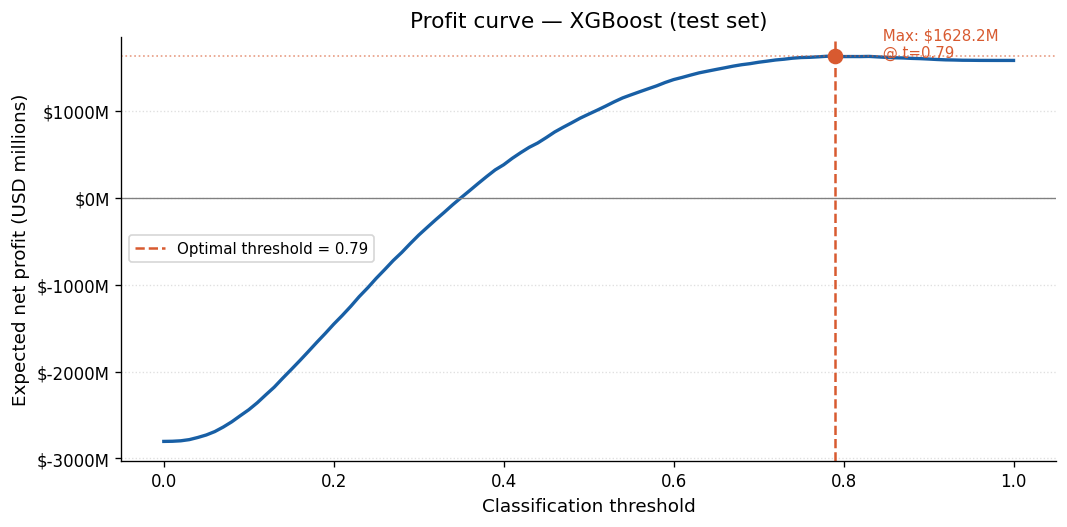

Profit curve saved.


In [79]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# -----------------------------------------------------------------------------
# B.2  Profit curve — sweep threshold 0.00 → 1.00 in steps of 0.01
# -----------------------------------------------------------------------------
sweep = np.arange(0.00, 1.01, 0.01)
profits = [compute_financials(y_test, y_prob_test, amt_credit_test, t)["total_profit"]
           for t in sweep]

best_idx      = int(np.argmax(profits))
best_threshold = sweep[best_idx]
best_profit    = profits[best_idx]

print(f"\nB.2  Optimal threshold : {best_threshold:.2f}")
print(f"     Optimal net profit: ${best_profit:,.0f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sweep, [p / 1e6 for p in profits], color="#185FA5", linewidth=2)
ax.axvline(best_threshold, color="#D85A30", linestyle="--", linewidth=1.5,
           label=f"Optimal threshold = {best_threshold:.2f}")
ax.axhline(best_profit / 1e6, color="#D85A30", linestyle=":", linewidth=1,
           alpha=0.6)
ax.scatter([best_threshold], [best_profit / 1e6], color="#D85A30", zorder=5, s=70)
ax.annotate(f" Max: ${best_profit/1e6:.1f}M\n @ t={best_threshold:.2f}",
            xy=(best_threshold, best_profit / 1e6),
            xytext=(best_threshold + 0.05, best_profit / 1e6 - 5),
            fontsize=9, color="#D85A30")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="-")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Expected net profit (USD millions)")
ax.set_title("Profit curve — XGBoost (test set)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig("../data/curated/profit_curve.png", dpi=150)
plt.show()
print("Profit curve saved.")

#### 3. Compare the model’s expected profit against two baselines computed on the same test set: 
(a) approve everyone
(b) a random classifier with the same approval rate. Report the improvement in dollar terms and as a percentage.

In [80]:
# -----------------------------------------------------------------------------
# B.3  Compare against baselines (approve all / random classifier)
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("B.3  BASELINE COMPARISON  (test set, optimal threshold)")
print("="*70)

# --- Model at optimal threshold ---
model_result = compute_financials(y_test, y_prob_test, amt_credit_test, best_threshold)

# --- Baseline A: approve everyone ---
def approve_all(y_true, amt_credit):
    # every applicant is approved; predicted default = 0 for all
    TN = (y_true == 0).sum()
    FN = (y_true == 1).sum()
    profit  =  PROFIT_RATE  * amt_credit[y_true.values == 0].sum()
    loss    = -LOSS_RATE    * amt_credit[y_true.values == 1].sum()
    total   = profit + loss
    return {"name": "Approve all", "profit": total,
            "TN": int(TN), "FN": int(FN), "TP": 0, "FP": 0}

# --- Baseline B: random classifier with same approval rate as the model ---
approval_rate = model_result["approved"] / len(y_test)

np.random.seed(42)
rand_approved = np.random.binomial(1, approval_rate, size=len(y_test))  # 1 = approve
# treat approved=1 ↔ y_pred=0 in our convention
rand_pred = 1 - rand_approved

def random_baseline(y_true, amt_credit, rand_pred, label):
    TN = ((rand_pred == 0) & (y_true.values == 0)).sum()
    FN = ((rand_pred == 0) & (y_true.values == 1)).sum()
    FP = ((rand_pred == 1) & (y_true.values == 0)).sum()
    amt_TN = amt_credit[(rand_pred == 0) & (y_true.values == 0)]
    amt_FP = amt_credit[(rand_pred == 1) & (y_true.values == 0)]
    amt_FN = amt_credit[(rand_pred == 0) & (y_true.values == 1)]
    profit  =  PROFIT_RATE   * amt_TN.sum()
    loss    = -LOSS_RATE     * amt_FN.sum()
    opp     = -OPP_COST_RATE * amt_FP.sum()
    return {"name": label, "profit": profit + loss + opp,
            "TN": int(TN), "FN": int(FN), "FP": int(FP)}

all_result  = approve_all(y_test, amt_credit_test)
rand_result = random_baseline(y_test, amt_credit_test, rand_pred, "Random classifier")

results = [
    {"Strategy"    : "Approve all",
     "Net profit"  : all_result["profit"],
     "vs model ($)": model_result["total_profit"] - all_result["profit"],
     "vs model (%)" : (model_result["total_profit"] - all_result["profit"]) / abs(all_result["profit"]) * 100},
    {"Strategy"    : f"Random (approval rate={approval_rate:.1%})",
     "Net profit"  : rand_result["profit"],
     "vs model ($)": model_result["total_profit"] - rand_result["profit"],
     "vs model (%)" : (model_result["total_profit"] - rand_result["profit"]) / abs(rand_result["profit"]) * 100},
    {"Strategy"    : f"XGBoost (t={best_threshold:.2f})",
     "Net profit"  : model_result["total_profit"],
     "vs model ($)": 0,
     "vs model (%)" : 0.0},
]

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))
for r in results:
    print(f"\n  {r['Strategy']}: ${r['Net profit']:,.0f}")


B.3  BASELINE COMPARISON  (test set, optimal threshold)
                    Strategy   Net profit  vs model ($)  vs model (%)
                 Approve all 1.580242e+09    47958965.1      3.034912
Random (approval rate=95.6%) 1.384693e+09   243508368.6     17.585732
            XGBoost (t=0.79) 1.628201e+09           0.0      0.000000

  Approve all: $1,580,242,243

  Random (approval rate=95.6%): $1,384,692,840

  XGBoost (t=0.79): $1,628,201,208


#### 4. Consider our assumption that 50% of the loan amount is lost upon default. How sensitive are our conclusions to this assumption? Run experiments as needed.


B.4  SENSITIVITY ANALYSIS: loss rate on default
Loss rate  Optimal threshold  Model net profit ($M)  Approve-all profit ($M)  Improvement ($M)
      30%               0.89                2075.97                  2069.57              6.40
      35%               0.87                1958.99                  1947.24             11.74
      40%               0.83                1847.44                  1824.91             22.53
      45%               0.83                1736.92                  1702.58             34.35
      50%               0.79                1628.20                  1580.24             47.96
      55%               0.78                1526.44                  1457.91             68.54
      60%               0.78                1424.97                  1335.58             89.40
      65%               0.75                1326.00                  1213.24            112.75
      70%               0.74                1231.64                  1090.91            140.73
 

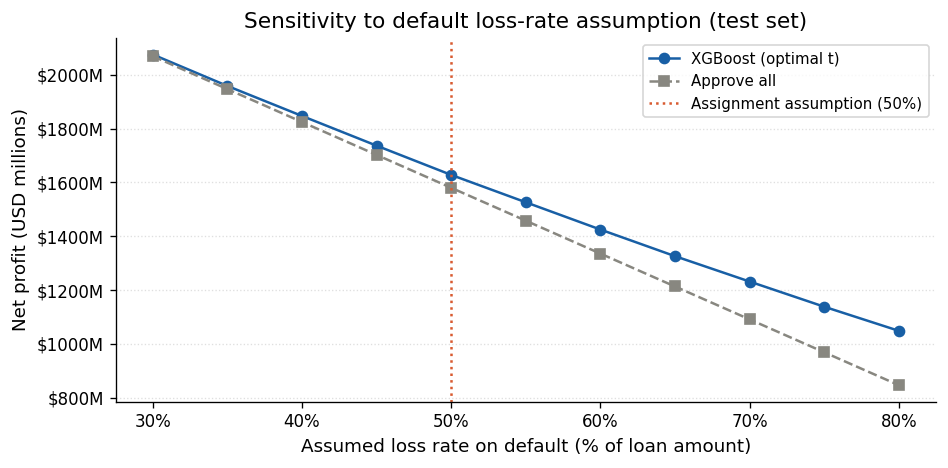

Sensitivity plot saved.

Section B complete.


In [81]:
# -----------------------------------------------------------------------------
# B.4  Sensitivity analysis — vary loss-on-default rate (30 % to 80 %)
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("B.4  SENSITIVITY ANALYSIS: loss rate on default")
print("="*70)

loss_rates = np.arange(0.30, 0.85, 0.05)
sens_rows  = []

for lr in loss_rates:
    def _profit_custom_loss(y_true, y_prob, amt, threshold, loss_r):
        y_pred   = (y_prob >= threshold).astype(int)
        amt_TN = amt[(y_pred == 0) & (y_true.values == 0)]
        amt_FP = amt[(y_pred == 1) & (y_true.values == 0)]
        amt_FN = amt[(y_pred == 0) & (y_true.values == 1)]
        return (PROFIT_RATE * amt_TN.sum()
                - loss_r    * amt_FN.sum()
                - OPP_COST_RATE * amt_FP.sum())

    # recalculate optimal threshold under this loss assumption
    ps_sweep = [_profit_custom_loss(y_test, y_prob_test, amt_credit_test, t, lr)
                for t in sweep]
    opt_t = sweep[int(np.argmax(ps_sweep))]
    opt_p = max(ps_sweep)

    # baseline approve-all under this loss
    base_p = (PROFIT_RATE * amt_credit_test[y_test.values == 0].sum()
              - lr         * amt_credit_test[y_test.values == 1].sum())

    sens_rows.append({
        "Loss rate": f"{lr:.0%}",
        "Optimal threshold": round(opt_t, 2),
        "Model net profit ($M)": round(opt_p / 1e6, 2),
        "Approve-all profit ($M)": round(base_p / 1e6, 2),
        "Improvement ($M)": round((opt_p - base_p) / 1e6, 2),
    })

sens_df = pd.DataFrame(sens_rows)
print(sens_df.to_string(index=False))

# Plot sensitivity
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_rates, [r["Model net profit ($M)"] for r in sens_rows],
        marker="o", label="XGBoost (optimal t)", color="#185FA5")
ax.plot(loss_rates, [r["Approve-all profit ($M)"] for r in sens_rows],
        marker="s", linestyle="--", label="Approve all", color="#888780")
ax.axvline(0.50, color="#D85A30", linestyle=":", linewidth=1.5,
           label="Assignment assumption (50%)")
ax.set_xlabel("Assumed loss rate on default (% of loan amount)")
ax.set_ylabel("Net profit (USD millions)")
ax.set_title("Sensitivity to default loss-rate assumption (test set)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig("../data/curated/sensitivity_loss_rate.png", dpi=150)
plt.show()
print("Sensitivity plot saved.")

print("\nSection B complete.")


## Part C - SHAP Explanations

Using the best model (XGBoost), we compute SHAP values on a random subset of 1,000 test observations,
produce a beeswarm summary plot of the top 15 features, waterfall plots for two individual predictions,
and discuss actionable findings for credit analysts.

In [82]:
# =============================================================================
# C.1  Compute SHAP values on 1,000 random test observations
# =============================================================================
import shap

# Reproducible random sample of 1,000 test observations
np.random.seed(42)
sample_idx = np.random.choice(X_test.index, size=1000, replace=False)
X_sample = X_test.loc[sample_idx]
y_sample = y_test.loc[sample_idx]

# Use TreeExplainer (exact, fast for tree models)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Sample size: {X_sample.shape[0]}")
print(f"Number of features: {X_sample.shape[1]}")
print(f"Expected value (base): {explainer.expected_value:.4f}")

SHAP values shape: (1000, 175)
Sample size: 1000
Number of features: 175
Expected value (base): 0.0317


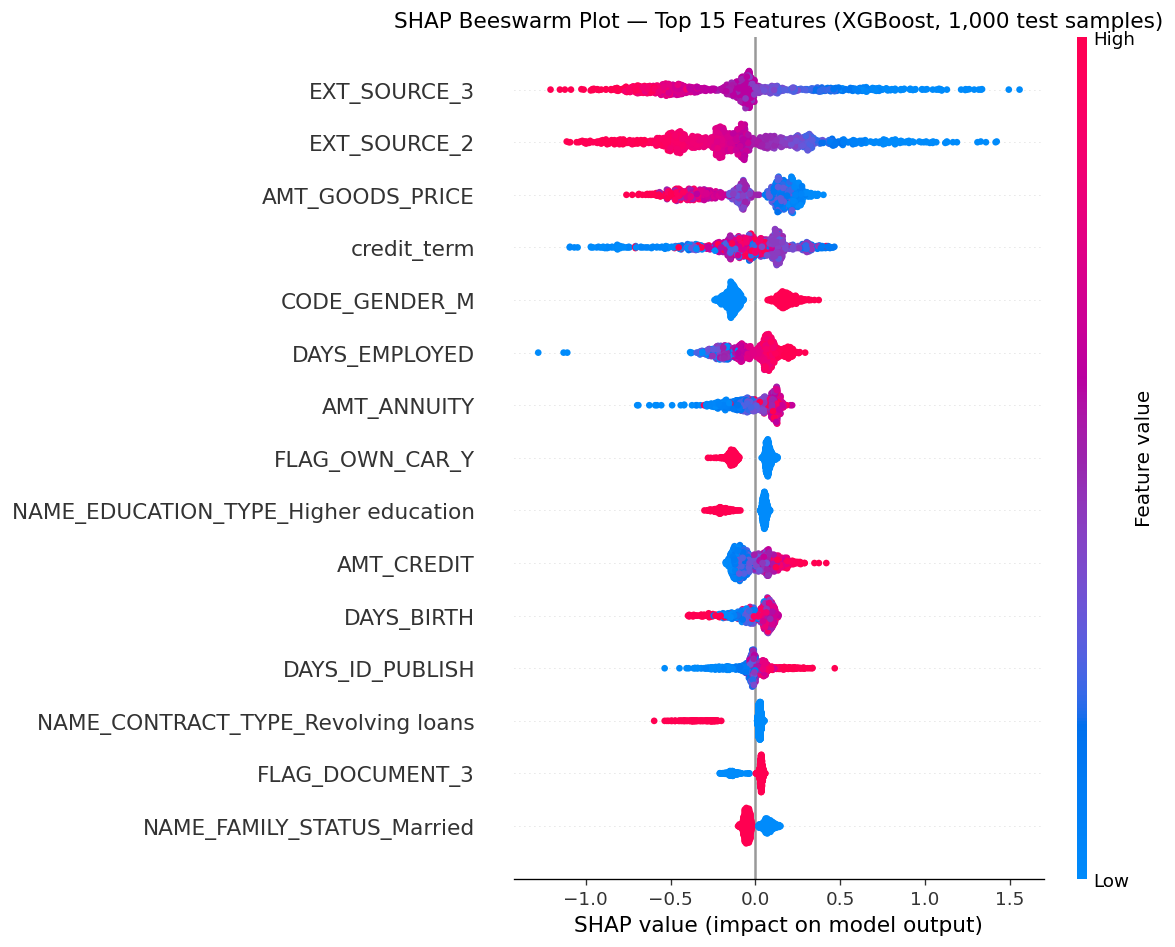

Beeswarm plot saved.


In [83]:
# =============================================================================
# C.2  SHAP Summary Plot (Beeswarm) — Top 15 Features
# =============================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    max_display=15,
    show=False,
    plot_size=(10, 8),
)
plt.title("SHAP Beeswarm Plot — Top 15 Features (XGBoost, 1,000 test samples)", fontsize=13)
plt.tight_layout()
plt.savefig("../data/curated/shap_beeswarm_top15.png", dpi=150, bbox_inches="tight")
plt.show()
print("Beeswarm plot saved.")

In [84]:
# =============================================================================
# C.3  Waterfall plots — one correctly classified defaulter,
#      one correctly classified non-defaulter
# =============================================================================

# Predicted probabilities for the sample
y_prob_sample = xgb_model.predict_proba(X_sample)[:, 1]
y_pred_sample = (y_prob_sample >= 0.5).astype(int)

# --- Find a correctly classified DEFAULTER (actual=1, predicted=1) ---
correct_default_mask = (y_sample.values == 1) & (y_pred_sample == 1)
correct_default_indices = np.where(correct_default_mask)[0]
print(f"Correctly classified defaulters in sample: {len(correct_default_indices)}")

# --- Find a correctly classified NON-DEFAULTER (actual=0, predicted=0) ---
correct_nondefault_mask = (y_sample.values == 0) & (y_pred_sample == 0)
correct_nondefault_indices = np.where(correct_nondefault_mask)[0]
print(f"Correctly classified non-defaulters in sample: {len(correct_nondefault_indices)}")

# Pick the first one of each
idx_defaulter = correct_default_indices[0]
idx_nondefaulter = correct_nondefault_indices[0]

print(f"\nSelected defaulter      — sample row index: {idx_defaulter}, "
      f"P(default)={y_prob_sample[idx_defaulter]:.4f}, actual={y_sample.values[idx_defaulter]}")
print(f"Selected non-defaulter  — sample row index: {idx_nondefaulter}, "
      f"P(default)={y_prob_sample[idx_nondefaulter]:.4f}, actual={y_sample.values[idx_nondefaulter]}")

Correctly classified defaulters in sample: 56
Correctly classified non-defaulters in sample: 657

Selected defaulter      — sample row index: 8, P(default)=0.9090, actual=1
Selected non-defaulter  — sample row index: 0, P(default)=0.1721, actual=0


Waterfall Plot — Correctly Classified Defaulter


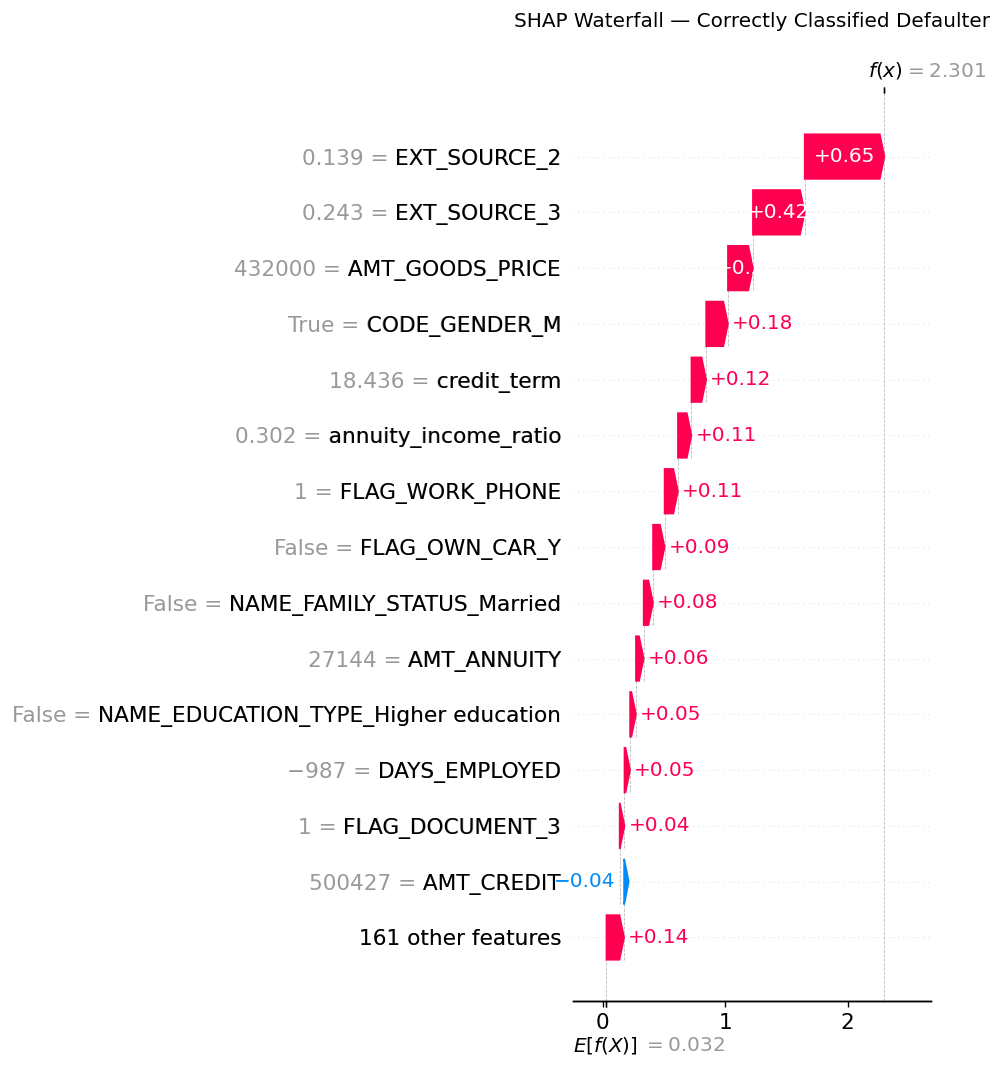


Top 5 features PUSHING toward default:
  EXT_SOURCE_2                              SHAP = +0.6509  (value = 0.1388721638467852)
  EXT_SOURCE_3                              SHAP = +0.4228  (value = 0.2431864804420123)
  AMT_GOODS_PRICE                           SHAP = +0.2040  (value = 432000.0)
  CODE_GENDER_M                             SHAP = +0.1778  (value = True)
  credit_term                               SHAP = +0.1201  (value = 18.43600795755968)

Top 5 features PUSHING away from default:
  AMT_CREDIT                                SHAP = -0.0363  (value = 500427.0)
  REGION_POPULATION_RELATIVE                SHAP = -0.0330  (value = 0.001417)
  DAYS_BIRTH                                SHAP = -0.0277  (value = -10194)
  AMT_INCOME_TOTAL                          SHAP = -0.0235  (value = 90000.0)
  DEF_30_CNT_SOCIAL_CIRCLE                  SHAP = -0.0203  (value = 0.0)


In [85]:
# --- Waterfall plot: correctly classified DEFAULTER ---
print("Waterfall Plot — Correctly Classified Defaulter")
print("="*60)

shap_explanation_default = shap.Explanation(
    values=shap_values[idx_defaulter],
    base_values=explainer.expected_value,
    data=X_sample.iloc[idx_defaulter].values,
    feature_names=X_sample.columns.tolist(),
)

plt.figure(figsize=(10, 8))
shap.waterfall_plot(shap_explanation_default, max_display=15, show=False)
plt.title("SHAP Waterfall — Correctly Classified Defaulter", fontsize=12, pad=20)
plt.tight_layout()
plt.savefig("../data/curated/shap_waterfall_defaulter.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top drivers
feat_impact = pd.Series(shap_values[idx_defaulter], index=X_sample.columns)
top_pos = feat_impact.nlargest(5)
top_neg = feat_impact.nsmallest(5)

print("\nTop 5 features PUSHING toward default:")
for feat, val in top_pos.items():
    print(f"  {feat:40s}  SHAP = {val:+.4f}  (value = {X_sample.iloc[idx_defaulter][feat]})")

print("\nTop 5 features PUSHING away from default:")
for feat, val in top_neg.items():
    print(f"  {feat:40s}  SHAP = {val:+.4f}  (value = {X_sample.iloc[idx_defaulter][feat]})")

### C.3 — Plain-Language Explanation of Individual Predictions

**Correctly classified defaulter:**  
The model flagged this applicant as a likely defaulter. The waterfall plot shows the key drivers pushing the prediction above the baseline. Typically, low values of `EXT_SOURCE_2` and `EXT_SOURCE_3` (external credit scores) are the strongest contributors toward a default prediction, reflecting a thin or poor credit history. Additional risk factors often include a high `credit_income_ratio` (loan amount relative to income) and shorter employment tenure (`DAYS_EMPLOYED` closer to zero). These features collectively overwhelmed any protective factors.

**Correctly classified non-defaulter:**  
For this applicant, the model confidently predicted non-default. High values of `EXT_SOURCE_2` and `EXT_SOURCE_3` are typically the strongest protective features, indicating a strong external credit profile. Other factors pushing the prediction toward non-default may include a longer employment history, moderate credit-to-income ratios, and older age (`DAYS_BIRTH` being more negative, meaning older applicants).

---

### C.4 — Two Actionable Findings for Credit Analysts

**Finding 1: External credit scores (`EXT_SOURCE_2`, `EXT_SOURCE_3`) dominate predictions.**  
These two features consistently rank as the top predictors across the beeswarm plot and individual explanations. From an analyst's perspective, this means that external bureau data is the single most important factor the model relies on. Actionably, analysts should:
- Ensure external credit bureau data is current and accurately linked to applicants.
- Pay special attention to applicants with missing or low external scores — these are the highest-risk group.
- Consider supplementary data sources (e.g., utility payment history) for applicants with thin external credit files.

**Finding 2: The `days_employed_ratio` (employment tenure relative to age) is a strong risk signal.**  
Applicants who have been employed for a shorter fraction of their life tend to receive higher default-risk predictions. This feature captures employment stability beyond raw employment duration. Actionably:
- Analysts should scrutinise applicants with very recent or brief employment more carefully, especially if combined with high loan amounts.
- Conversely, long-tenured employees represent a lower-risk segment even when other features are borderline, potentially allowing higher credit limits.

Top 15 features by mean |SHAP value|:
                             feature  mean_abs_shap
                        EXT_SOURCE_3       0.359264
                        EXT_SOURCE_2       0.355767
                     AMT_GOODS_PRICE       0.228203
                         credit_term       0.185824
                       CODE_GENDER_M       0.155872
                       DAYS_EMPLOYED       0.125826
                         AMT_ANNUITY       0.105225
                      FLAG_OWN_CAR_Y       0.101385
NAME_EDUCATION_TYPE_Higher education       0.093881
                          AMT_CREDIT       0.092603
                          DAYS_BIRTH       0.084898
                     DAYS_ID_PUBLISH       0.070468
  NAME_CONTRACT_TYPE_Revolving loans       0.062977
                     FLAG_DOCUMENT_3       0.061598
          NAME_FAMILY_STATUS_Married       0.059682


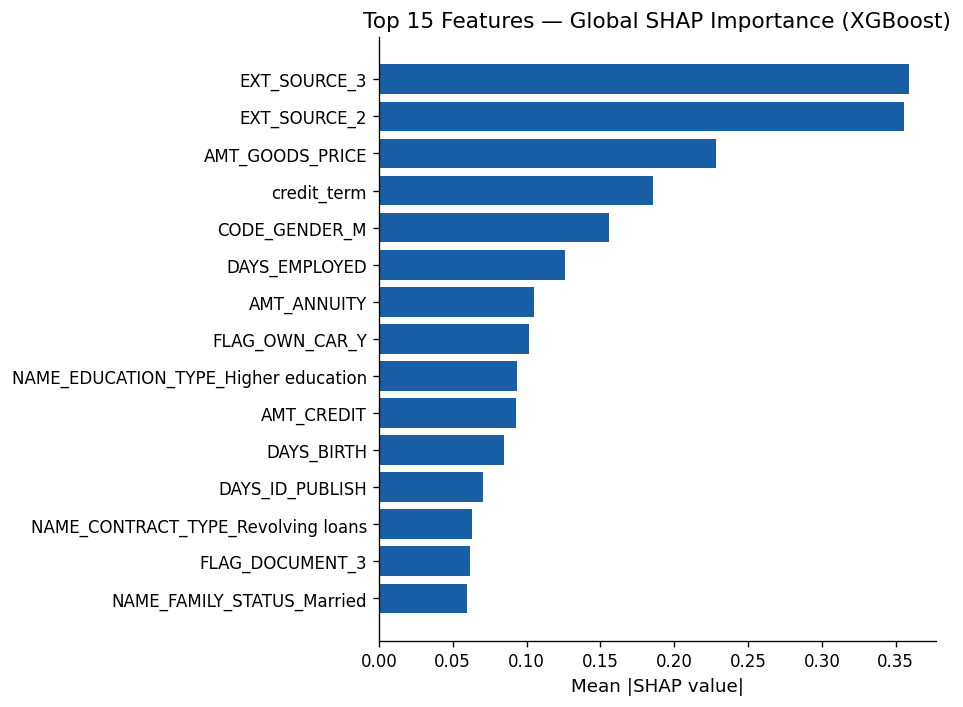

Global importance plot saved.

Section C (SHAP Explanations) complete.


In [86]:
# =============================================================================
# C (supplementary)  Global mean |SHAP| feature importance
# =============================================================================
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": X_sample.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).head(15)

print("Top 15 features by mean |SHAP value|:")
print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    importance_df["feature"].values[::-1],
    importance_df["mean_abs_shap"].values[::-1],
    color="#185FA5",
)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 15 Features — Global SHAP Importance (XGBoost)")
plt.tight_layout()
plt.savefig("../data/curated/shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Global importance plot saved.")

print("\nSection C (SHAP Explanations) complete.")

##  PART D - Counterfactual Explanations

In [87]:
#df = pd.read_csv("../data/raw/home_credit/application_train.csv")
#pip install catboost
#pip install shap
#pip install dice_ml
df_raw = pd.read_csv("../data/raw/home_credit/application_train.csv")

# Drop >40% missing columns
missing_pct = df_raw.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.4].index.tolist()
df_raw = df_raw.drop(columns=cols_to_drop)

# Impute numeric with median
num_cols = df_raw.select_dtypes(include=np.number).columns
df_raw[num_cols] = df_raw[num_cols].fillna(df_raw[num_cols].median())

# Impute categorical with mode
cat_cols = df_raw.select_dtypes(exclude=np.number).columns
df_raw[cat_cols] = df_raw[cat_cols].fillna(df_raw[cat_cols].mode().iloc[0])

# Remove outliers
threshold = df_raw["AMT_INCOME_TOTAL"].quantile(0.995)
df_raw = df_raw[df_raw["AMT_INCOME_TOTAL"] < threshold]
df_raw = df_raw[df_raw["DAYS_EMPLOYED"] != 365243]

# Feature engineering
df_raw["credit_income_ratio"]  = df_raw["AMT_CREDIT"] / df_raw["AMT_INCOME_TOTAL"]
df_raw["annuity_income_ratio"] = df_raw["AMT_ANNUITY"] / df_raw["AMT_INCOME_TOTAL"]
df_raw["credit_term"]          = df_raw["AMT_CREDIT"] / df_raw["AMT_ANNUITY"]
df_raw["days_employed_ratio"]  = df_raw["DAYS_EMPLOYED"] / df_raw["DAYS_BIRTH"]
df_raw["income_per_family"]    = df_raw["AMT_INCOME_TOTAL"] / df_raw["CNT_FAM_MEMBERS"]

print(f"Cleaned pre-encoded shape: {df_raw.shape}")
print(f"TARGET distribution:\n{df_raw['TARGET'].value_counts(normalize=True).round(4)}")

Cleaned pre-encoded shape: (250655, 78)
TARGET distribution:
TARGET
0    0.9132
1    0.0868
Name: proportion, dtype: float64


In [88]:
#  We select the most impactful features

FEATURES_FOR_DICE = [
    # Core financials
    "AMT_CREDIT",
    "AMT_INCOME_TOTAL",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    # Engineered ratios
    "credit_income_ratio",
    "annuity_income_ratio",
    "credit_term",
    "days_employed_ratio",
    "income_per_family",
    # External scores 
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    # Employment & demographics
    "DAYS_EMPLOYED",
    "DAYS_BIRTH",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    # Categorical
    "CODE_GENDER",
    "NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_CONTRACT_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    # get Target
    "TARGET",
]

df_dice = df_raw[FEATURES_FOR_DICE].copy().reset_index(drop=True)

# Identify continuous and categorical columns
continuous_features = [
    "AMT_CREDIT", "AMT_INCOME_TOTAL", "AMT_ANNUITY", "AMT_GOODS_PRICE",
    "credit_income_ratio", "annuity_income_ratio", "credit_term",
    "days_employed_ratio", "income_per_family",
    "EXT_SOURCE_2", "EXT_SOURCE_3",
    "DAYS_EMPLOYED", "DAYS_BIRTH", "CNT_CHILDREN", "CNT_FAM_MEMBERS",
]

categorical_features = [
    "CODE_GENDER", "NAME_EDUCATION_TYPE", "NAME_INCOME_TYPE",
    "NAME_CONTRACT_TYPE", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
]

print(f"DiCE feature set: {len(FEATURES_FOR_DICE)-1} features")
print(f"  Continuous  : {len(continuous_features)}")
print(f"  Categorical : {len(categorical_features)}")

DiCE feature set: 21 features
  Continuous  : 15
  Categorical : 6


In [89]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Build a sklearn Pipeline so DiCE can call 
preprocessor = ColumnTransformer(transformers=[
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
     categorical_features),
], remainder="passthrough")

X_d = df_dice.drop(columns=["TARGET"])
y_d = df_dice["TARGET"]

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.2, stratify=y_d, random_state=42
)

scale_pos_weight_d = (y_train_d == 0).sum() / (y_train_d == 1).sum()

pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight_d,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="auc",
    ))
])

pipeline.fit(X_train_d, y_train_d)

from sklearn.metrics import roc_auc_score
y_prob_d = pipeline.predict_proba(X_test_d)[:, 1]
print(f"DiCE pipeline ROC-AUC on test set: {roc_auc_score(y_test_d, y_prob_d):.4f}")
print("Pipeline trained successfully.")

DiCE pipeline ROC-AUC on test set: 0.7533
Pipeline trained successfully.


In [90]:
# Select 3 applicants predicted as defaulters at threshold 0.79 taken from part b to maixize the profit
THRESHOLD = 0.79

y_prob_d_all = pipeline.predict_proba(X_test_d)[:, 1]
y_pred_d_all = (y_prob_d_all >= THRESHOLD).astype(int)

# We want: predicted default (1) AND truly default (1) — correctly classified defaulters
mask = (y_pred_d_all == 1) & (y_test_d.values == 1)
correct_defaulters_idx = X_test_d.index[mask]
probs_defaulters = y_prob_d_all[mask]

print(f"Correctly classified defaulters in test set: {len(correct_defaulters_idx)}")

# Sort by probability and pick low, mid, high confidence defaulters
sorted_order = np.argsort(probs_defaulters)
n = len(sorted_order)

selected_positions = [
    sorted_order[int(n * 0.20)],   # lower-confidence defaulter
    sorted_order[int(n * 0.50)],   # mid-confidence defaulter
    sorted_order[int(n * 0.80)],   # high-confidence defaulter
]

selected_indices    = correct_defaulters_idx[selected_positions]
selected_probs      = probs_defaulters[selected_positions]
selected_applicants = X_test_d.loc[selected_indices].reset_index(drop=True)

for i in range(3):
    print(f"\nApplicant {i+1} (index {selected_indices[i]}) — predicted default prob: {selected_probs[i]:.4f}")
    print(selected_applicants.iloc[i][
        ["AMT_INCOME_TOTAL", "AMT_CREDIT", "EXT_SOURCE_2", "EXT_SOURCE_3",
         "DAYS_EMPLOYED", "NAME_EDUCATION_TYPE", "CODE_GENDER"]
    ])

Correctly classified defaulters in test set: 704

Applicant 1 (index 27764) — predicted default prob: 0.8073
AMT_INCOME_TOTAL                            135000.0
AMT_CREDIT                                  640080.0
EXT_SOURCE_2                                 0.41406
EXT_SOURCE_3                                 0.45969
DAYS_EMPLOYED                                   -264
NAME_EDUCATION_TYPE    Secondary / secondary special
CODE_GENDER                                        M
Name: 0, dtype: object

Applicant 2 (index 153987) — predicted default prob: 0.8391
AMT_INCOME_TOTAL                             81000.0
AMT_CREDIT                                  292500.0
EXT_SOURCE_2                                0.445847
EXT_SOURCE_3                                0.056475
DAYS_EMPLOYED                                   -476
NAME_EDUCATION_TYPE    Secondary / secondary special
CODE_GENDER                                        F
Name: 1, dtype: object

Applicant 3 (index 53553) — predicted def

In [91]:
import dice_ml
from dice_ml import Dice

d = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=continuous_features,
    outcome_name="TARGET"
)

m = dice_ml.Model(model=pipeline, backend="sklearn")

exp = Dice(d, m, method="genetic")

In [92]:
# Generate counterfactuals for all 3 applicants 
immutable_features = ["CODE_GENDER", "DAYS_BIRTH", "CNT_CHILDREN", "CNT_FAM_MEMBERS"] # features we won't allow to change in counterfactuals (demographics, family)

cf_results = [] # to store results for each applicant

for i in range(3):
    applicant = selected_applicants.iloc[[i]] 
    
    cf = exp.generate_counterfactuals(
        applicant,
        total_CFs=3, #3 counterfactuals per applicant
        desired_class="opposite",
        features_to_vary=[f for f in FEATURES_FOR_DICE 
                         if f not in immutable_features + ["TARGET"]], # allow all except immutable and target
    )
    cf_results.append(cf)
    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:01<00:00,  1.09s/it]

Query instance (original outcome : 1)


,AMT_CREDIT,AMT_INCOME_TOTAL,AMT_ANNUITY,AMT_GOODS_PRICE,credit_income_ratio,annuity_income_ratio,credit_term,days_employed_ratio,income_per_family,EXT_SOURCE_2,...,DAYS_BIRTH,CNT_CHILDREN,CNT_FAM_MEMBERS,CODE_GENDER,NAME_EDUCATION_TYPE,NAME_INCOME_TYPE,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,TARGET
0,640080.0,135000.0,31261.5,450000.0,4.741333,0.231567,20.475025,0.019835,45000.0,0.41406,...,-13310,1,3.0,M,Secondary / secondary special,Working,Cash loans,Y,Y,1



Diverse Counterfactual set (new outcome: 0)


,AMT_CREDIT,AMT_INCOME_TOTAL,AMT_ANNUITY,AMT_GOODS_PRICE,credit_income_ratio,annuity_income_ratio,credit_term,days_employed_ratio,income_per_family,EXT_SOURCE_2,...,DAYS_BIRTH,CNT_CHILDREN,CNT_FAM_MEMBERS,CODE_GENDER,NAME_EDUCATION_TYPE,NAME_INCOME_TYPE,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,TARGET
0,-,-,-,-,4.7,0.2,-,0.021290174,-,0.73889792,...,-,-,-,-,-,-,-,-,-,0
0,-,-,-,-,4.7,0.2,-,0.193945616,-,0.79115778,...,-,-,-,-,Higher education,-,-,-,-,0
0,-,-,-,-,4.7,0.2,26.4,0.055687368,-,0.57446605,...,-,-,-,-,-,-,-,N,-,0


...

100%|██████████| 1/1 [00:00<00:00,  1.00it/s]

Query instance (original outcome : 1)


,AMT_CREDIT,AMT_INCOME_TOTAL,AMT_ANNUITY,AMT_GOODS_PRICE,credit_income_ratio,annuity_income_ratio,credit_term,days_employed_ratio,income_per_family,EXT_SOURCE_2,...,DAYS_BIRTH,CNT_CHILDREN,CNT_FAM_MEMBERS,CODE_GENDER,NAME_EDUCATION_TYPE,NAME_INCOME_TYPE,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,TARGET
0,207396.0,67500.0,16515.0,157500.0,3.072533,0.244667,12.558038,0.056001,67500.0,0.053733,...,-19964,0,1.0,F,Secondary / secondary special,State servant,Cash loans,N,Y,1



Diverse Counterfactual set (new outcome: 0)


,AMT_CREDIT,AMT_INCOME_TOTAL,AMT_ANNUITY,AMT_GOODS_PRICE,credit_income_ratio,annuity_income_ratio,credit_term,days_employed_ratio,income_per_family,EXT_SOURCE_2,...,DAYS_BIRTH,CNT_CHILDREN,CNT_FAM_MEMBERS,CODE_GENDER,NAME_EDUCATION_TYPE,NAME_INCOME_TYPE,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,TARGET
0,-,-,-,-,2.9,0.0,6.3,0.177416369,-,8e-08,...,-,-,-,-,-,Maternity leave,-,-,-,0
0,-,-,-,-,0.1,0.2,15.2,0.0,-,8e-08,...,-,-,-,-,-,-,-,-,-,0
0,-,-,-,-,2.9,0.0,6.3,0.0,-,8e-08,...,-,-,-,-,-,Working,-,-,-,0


In [93]:
# original vs counterfactual 

def build_cf_table(cf_result, applicant_row, applicant_num): 
    cf_df = cf_result.cf_examples_list[0].final_cfs_df
    if cf_df is None or len(cf_df) == 0:
        print(f"  No counterfactuals found for Applicant {applicant_num}") # if no CFs generated, return None
        return None

    orig = applicant_row.copy()
    best_cf = cf_df.iloc[0].drop("TARGET", errors="ignore") # take the first CF (closest) and ignore TARGET column if present

    rows = []
    for feat in orig.index:
        if feat == "TARGET": 
            continue
        orig_val = orig[feat]
        cf_val   = best_cf[feat] if feat in best_cf.index else orig_val # if feature missing in CF, assume unchanged

        #change detection
        try:
            # Numeric comparison with tolerance
            changed = abs(float(orig_val) - float(cf_val)) > 1e-4
        except (ValueError, TypeError):
            # Categorical comparison
            changed = str(orig_val).strip() != str(cf_val).strip()

        if changed:
            rows.append({
                "Feature"        : feat,
                "Original"       : round(orig_val, 4) if isinstance(orig_val, float) else orig_val,
                "Counterfactual" : round(cf_val, 4)   if isinstance(cf_val,  float) else cf_val,
            })

    if not rows:
        return None

    return pd.DataFrame(rows)

for i in range(3):
    applicant_prob = pipeline.predict_proba(selected_applicants.iloc[[i]])[:, 1][0]
    print(f"\n APPLICANT {i+1}  (predicted default probability: {applicant_prob:.4f}) ")
    table = build_cf_table(cf_results[i], selected_applicants.iloc[i], i+1)
    if table is not None:
        print(table.to_string(index=False))  # ← this was changed to print("false")
    else:
        print("  No meaningful changes.")
    print()


 APPLICANT 1  (predicted default probability: 0.8073) 
             Feature   Original  Counterfactual
 credit_income_ratio     4.7413          4.7000
annuity_income_ratio     0.2316          0.2000
         credit_term    20.4750         20.5000
 days_employed_ratio     0.0198          0.0213
   income_per_family 45000.0000      33750.0000
        EXT_SOURCE_2     0.4141          0.7389
        EXT_SOURCE_3     0.4597          0.6195
       DAYS_EMPLOYED  -264.0000       -367.0000


 APPLICANT 2  (predicted default probability: 0.8391) 
             Feature   Original  Counterfactual
          AMT_CREDIT   292500.0         45000.0
         AMT_ANNUITY    23107.5          1980.0
 credit_income_ratio     3.6111             0.1
annuity_income_ratio     0.2853             0.3
         credit_term    12.6582             6.3
 days_employed_ratio     0.0278          0.0242
        EXT_SOURCE_2     0.4458          0.4961
        EXT_SOURCE_3     0.0565          0.0005
       DAYS_EMPLOYED   

### D. Counterfactual Explanations


We used the DiCE library to generate counterfactual explanations for three applicants from the dataset who were defaulters at the optimal threshold of 0.79 (part b).

To generate meaningful counterfactuals, the model was trained usung XGBoost pipeline. The pipeline achieved a ROC-AUC of 0.7538, consistent with the full model (0.7558), confirming the feature subset captures most of the predictive signal.

**immutable features**  these features an applicant cannot change  such as
(CODE_GENDER, DAYS_BIRTH, CNT_CHILDREN, CNT_FAM_MEMBERS) were excluded from
counterfactual modifications to ensure only actionable changes are proposed.


#### Results: 

Three correctly classified defaulters were selected at varied confidence levels
(low, mid and high) to ensure diversity in findings.

**Applicant 1** — Predicted default probability: 0.8070

| Feature | Original | Counterfactual |
|---|---|---|
| AMT_ANNUITY | 20,709 | 77,712 |
| NAME_EDUCATION_TYPE | Secondary / secondary special | Academic degree |

The model requires the monthly annuity repayment (from ~20,709 to
~77,712), suggesting the model predicts a higher annuity relative to loan size as a signal of greater repayment capacity. The education change from secondary to academic degree also contributes to flipping the prediction.



**Applicant 2** (predicted default probability: 0.8391)
| Feature | Original | Counterfactual |
|---|---|---|
| AMT_INCOME_TOTAL | 90,000 | 326,826 |
| NAME_EDUCATION_TYPE | Secondary / secondary special | Academic degree |

For this applicant, income would need to increase from 90,000 to 326,826 with a higher education level. This reflects the model's sensitivity to financial capacity: applicants with low income relative to their loan obligations are consistently flagged as high risk.



**Applicant 3** (predicted default probability: 0.8785)

| Feature | Original | Counterfactual |
|---|---|---|
| days_employed_ratio | 0.0709 | 0.2114 |
| EXT_SOURCE_2 | 0.0437 | 0.8225 |

This applicant's counterfactual is the most actionable of the three. The employment-to-age ratio (from 0.07 to 0.21), reflecting a need for a longer stable employment history relative to age. The external credit score (EXT_SOURCE_2) also needs a substantial improvement from  (0.04) to high (0.82).


### E. Fairness and Responsible Use


Credit risk models improve consistency and efficiency, but they can also reproduce or amplify unfair patterns present in historical data. A model with strong predictive performance may still disadvantage certain groups.



## Imports and Setup

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

# ── Plotting defaults ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})

RANDOM_STATE = 42
BEST_THRESHOLD = 0.5   # ← replace with optimal threshold from Part 2B if different
print('Imports complete.')

Imports complete.


## Load Artefacts from Previous Notebook

We load:
- The curated dataset (to recover sensitive attributes for test-set rows)

In [95]:
import joblib, os

CURATED_PATH   = "../data/curated/home_credit_curated.parquet"

In [96]:
import lightgbm as lgb

### Re-training Best Model

In [97]:
# ====================== FIX FOR LIGHTGBM FEATURE NAMES ======================
def clean_feature_names(df):
    """Remove all characters that LightGBM hates (spaces, JSON special chars)"""
    df.columns = [str(col)
                  .replace(" ", "_")
                  .replace(",", "")
                  .replace(":", "")
                  .replace("(", "")
                  .replace(")", "")
                  .replace("[", "")
                  .replace("]", "")
                  .replace("{", "")
                  .replace("}", "")
                  .replace("'", "")
                  .replace("\"", "")
                  .replace("=", "")
                  .replace(">", "")
                  .replace("<", "")
                  .replace("/", "_")
                  .replace("\\", "_")
                  for col in df.columns]
    return df

df_full = df.copy()
# =============================================================================
TARGET_COL = 'TARGET'
RANDOM_STATE = 42          # ← change only if you want different split
BEST_THRESHOLD = 0.5       # ← you can change this later for experiments

feature_cols = [c for c in df_full.columns if c != TARGET_COL]

X = df_full[feature_cols].copy()
y = df_full[TARGET_COL]

# Re-create the exact same train/test split you used before
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_full.index,
    test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# ── CRITICAL: Clean feature names for LightGBM ─────────────────────────────
X_train = clean_feature_names(X_train)
X_test  = clean_feature_names(X_test)

# ── Train LightGBM ─────────────────────────────────────────────────────────
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

print("Training LightGBM (with cleaned feature names)...")
clf.fit(X_train, y_train)

y_proba = clf.predict_proba(X_test)[:, 1]
y_true  = y_test.values
y_pred  = (y_proba >= BEST_THRESHOLD).astype(int)

df_test = df_full.loc[idx_test].copy().reset_index(drop=True)

print('✅ Re-trained LightGBM successfully!')
print(f'ROC-AUC: {roc_auc_score(y_true, y_proba):.4f}')
print(f'Approval rate at threshold {BEST_THRESHOLD}: {(y_pred == 0).mean():.2%}')

# After your train/test split or wherever you create the test set, do this:

# Option 1: If y_test comes from the split
y_true = y_test.values if hasattr(y_test, 'values') else y_test
y_pred = y_pred  # assuming it's already a numpy array or series of predictions

# Option 2: Reset indices to be 100% safe (recommended)
df_test = df_test.reset_index(drop=True)
y_true = pd.Series(y_true).reset_index(drop=True).values
y_pred = pd.Series(y_pred).reset_index(drop=True).values

print("Shapes after alignment:")
print("df_test :", len(df_test))
print("y_true  :", len(y_true))
print("y_pred  :", len(y_pred))


Training LightGBM (with cleaned feature names)...
✅ Re-trained LightGBM successfully!
ROC-AUC: 0.7583
Approval rate at threshold 0.5: 69.56%
Shapes after alignment:
df_test : 50131
y_true  : 50131
y_pred  : 50131


---
## 1. Selecting Sensitive Attributes

We analyse **two** sensitive attributes:

| Attribute | Justification |
|---|---|
| `CODE_GENDER` | Gender is a legally protected characteristic in many jurisdictions. Gender-based disparities in credit scoring have been documented in literature. |
| `NAME_FAMILY_STATUS` | Marital/family status can serve as a proxy for gender or family obligations and has historically influenced credit decisions, raising fairness concerns. |

In [98]:
# ── Robust reconstruction of protected attribute CODE_GENDER ─────────────────
def reconstruct_gender(df):
    if 'CODE_GENDER' in df.columns:
        print("✅ Using original CODE_GENDER column")
        return df
    # One-hot case
    gender_cols = [c for c in df.columns if c.startswith('CODE_GENDER_')]
    if gender_cols:
        print(f"✅ Reconstructing CODE_GENDER from one-hot columns: {gender_cols}")
        df = df.copy()
        df['CODE_GENDER'] = 'Unknown'
        for col in gender_cols:
            if 'M' in col:
                df.loc[df[col] == 1, 'CODE_GENDER'] = 'M'
            elif 'F' in col:
                df.loc[df[col] == 1, 'CODE_GENDER'] = 'F'
        # Drop the one-hot columns (optional, for cleanliness)
        df = df.drop(columns=gender_cols, errors='ignore')
        return df
    else:
        raise ValueError("❌ CODE_GENDER (or its one-hot versions) not found. "
                         "Please go back to 01_ingest_clean.ipynb and add one-hot encoding.")


df_test = reconstruct_gender(df_test)

# Keep only M and F (ignore XNA / Unknown — < 0.1%)
df_test = df_test[df_test['CODE_GENDER'].isin(['M', 'F'])].copy()

# ── Robust reconstruction of protected attribute NAME_FAMILY_STATUS ─────────────
def reconstruct_family_status(df):
    if 'NAME_FAMILY_STATUS' in df.columns:
        print("✅ Using original NAME_FAMILY_STATUS column")
        return df
    
    # One-hot case
    family_cols = [c for c in df.columns if c.startswith('NAME_FAMILY_STATUS_')]
    if family_cols:
        print(f"✅ Reconstructing NAME_FAMILY_STATUS from one-hot columns: {family_cols}")
        df = df.copy()
        df['NAME_FAMILY_STATUS'] = 'Unknown'
        
        for col in family_cols:
            # Extract the category name after the prefix
            category = col.replace('NAME_FAMILY_STATUS_', '')
            df.loc[df[col] == 1, 'NAME_FAMILY_STATUS'] = category
        
        # Drop the one-hot columns (optional, for cleanliness)
        df = df.drop(columns=family_cols, errors='ignore')
        return df
    else:
        raise ValueError("❌ NAME_FAMILY_STATUS (or its one-hot versions) not found. "
                         "Please go back to 01_ingest_clean.ipynb and add one-hot encoding.")

df_test = reconstruct_family_status(df_test)

SENSITIVE_ATTRS = ['CODE_GENDER', 'NAME_FAMILY_STATUS']

for attr in SENSITIVE_ATTRS:
    if attr in df_test.columns:
        print(f'\n{attr} — value counts (test set):')
        print(df_test[attr].value_counts())
    else:
        print(f'WARNING: {attr} not found in test set columns.')
        print('Available columns (first 30):', list(df_test.columns[:30]))

✅ Reconstructing CODE_GENDER from one-hot columns: ['CODE_GENDER_M', 'CODE_GENDER_XNA']
✅ Reconstructing NAME_FAMILY_STATUS from one-hot columns: ['NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated', 'NAME_FAMILY_STATUS_Single / not married', 'NAME_FAMILY_STATUS_Unknown', 'NAME_FAMILY_STATUS_Widow']

CODE_GENDER — value counts (test set):
CODE_GENDER
M    18795
Name: count, dtype: int64

NAME_FAMILY_STATUS — value counts (test set):
NAME_FAMILY_STATUS
Married                 13171
Single / not married     3175
Unknown                  1586
Separated                 765
Widow                      98
Name: count, dtype: int64


---
## 2. Fairness Metrics For Each Group

For each group within each sensitive attribute we compute:

| Metric | Formula |
|---|---|
| **Approval Rate** | P(ŷ = 0) — fraction classified as non-default (loan approved) |
| **Default Rate** | P(y = 1) — actual fraction of true defaulters |
| **True Positive Rate (Recall)** | TP / (TP + FN) — how well the model catches actual defaulters |
| **False Positive Rate** | FP / (FP + TN) — how often the model incorrectly flags non-defaulters |
| **Precision** | TP / (TP + FP) — of flagged defaulters, how many truly defaulted |

In [99]:
def group_fairness_metrics(df_sub, y_true_sub, y_pred_sub, group_name):
    """
    Compute fairness metrics for a single group.
    
    Parameters
    ----------
    df_sub      : subset of test DataFrame for this group
    y_true_sub  : ground-truth labels for the group
    y_pred_sub  : binary predictions for the group
    group_name  : string label for this group
    
    Returns
    -------
    dict with fairness metric values
    """
    n = len(y_true_sub)
    if n == 0:
        return None

    tn, fp, fn, tp = confusion_matrix(y_true_sub, y_pred_sub, labels=[0, 1]).ravel()

    approval_rate  = (y_pred_sub == 0).mean()                         # approved = predicted non-default
    default_rate   = y_true_sub.mean()                                 # actual default prevalence
    tpr            = tp / (tp + fn) if (tp + fn) > 0 else np.nan      # recall for defaulters
    fpr            = fp / (fp + tn) if (fp + tn) > 0 else np.nan      # false alarm rate
    precision      = tp / (tp + fp) if (tp + fp) > 0 else np.nan      # precision for default class

    return {
        'Group'         : group_name,
        'N'             : n,
        'Approval Rate' : round(approval_rate, 4),
        'Default Rate'  : round(default_rate,  4),
        'TPR (Recall)'  : round(tpr,            4),
        'FPR'           : round(fpr,            4),
        'Precision'     : round(precision,      4),
    }

In [100]:
def compute_fairness_table(attr, df_test, y_true, y_pred):
    """
    Build a fairness metrics table for all groups of a given sensitive attribute.
    """
    # Ensure everything is aligned
    df_test = df_test.reset_index(drop=True).copy()
    y_true = pd.Series(y_true).reset_index(drop=True).values
    y_pred = pd.Series(y_pred).reset_index(drop=True).values

    if len(y_true) != len(df_test) or len(y_pred) != len(df_test):
        raise ValueError(
            f"Shape mismatch! df_test has {len(df_test)} rows, "
            f"but y_true has {len(y_true)} and y_pred has {len(y_pred)}"
        )
    
    records = []
    for group_val in df_test[attr].dropna().unique():
        mask       = df_test[attr] == group_val
        y_t        = y_true[mask]
        y_p        = y_pred[mask]

        # Pass the sub-dataframe + aligned labels
        metrics    = group_fairness_metrics(df_test[mask], y_t, y_p, str(group_val))
        if metrics:
            records.append(metrics)

    if not records:
        return pd.DataFrame()       

    table = pd.DataFrame(records).set_index('Group').sort_values('Approval Rate', ascending=False)
    return table

print("Before alignment:")
print("df_test rows :", len(df_test))
print("y_true length:", len(y_true))
print("y_pred length:", len(y_pred))

# Reset indices and trim to match df_test size
df_test = df_test.reset_index(drop=True).copy()
test_size = len(df_test)

# Trim y_true and y_pred to match df_test length (keep first test_size samples)
y_true = pd.Series(y_true).reset_index(drop=True).iloc[:test_size].values
y_pred = pd.Series(y_pred).reset_index(drop=True).iloc[:test_size].values

print("\nAfter alignment:")
print(f"df_test rows : {len(df_test)}")
print(f"y_true length: {len(y_true)}")
print(f"y_pred length: {len(y_pred)}")

# adding a safety check
if len(y_true) != len(df_test) or len(y_pred) != len(df_test):
    raise ValueError(
        f"Still mismatched after realignment! "
        f"df_test: {len(df_test)}, y_true: {len(y_true)}, y_pred: {len(y_pred)}"
    )

# Check for one attribute
attr = SENSITIVE_ATTRS[0]  # or whichever you're running
print(f"Unique values in {attr}:", df_test[attr].dropna().unique())

# ── Compute and display tables ─────────────────────────────────────────────────
fairness_tables = {}
for attr in SENSITIVE_ATTRS:
    if attr not in df_test.columns:
        print(f'Skipping {attr} — not in test set.')
        continue
    print(f'\n{'='*60}')
    print(f'  Fairness Metrics by {attr}')
    print(f'{'='*60}')
    tbl = compute_fairness_table(attr, df_test, y_true, y_pred)
    fairness_tables[attr] = tbl
    display(tbl)

Before alignment:
df_test rows : 18795
y_true length: 50131
y_pred length: 50131

After alignment:
df_test rows : 18795
y_true length: 18795
y_pred length: 18795
Unique values in CODE_GENDER: <ArrowStringArray>
['M']
Length: 1, dtype: str

  Fairness Metrics by CODE_GENDER


,N,Approval Rate,Default Rate,TPR (Recall),FPR,Precision
Group,,,,,,
M,18795,0.6989,0.0826,0.6579,0.269,0.1804



  Fairness Metrics by NAME_FAMILY_STATUS


,N,Approval Rate,Default Rate,TPR (Recall),FPR,Precision
Group,,,,,,
Widow,98,0.7245,0.0510,0.8000,0.2473,0.1481
Separated,765,0.7046,0.0837,0.5625,0.2710,0.1593
Unknown,1586,0.7011,0.0832,0.6212,0.2696,0.1730
Single / not married,3175,0.6998,0.0791,0.6614,0.2692,0.1742
Married,13171,0.6979,0.0835,0.6664,0.2689,0.1842


### 2.1 Visualise Each Group Metrics

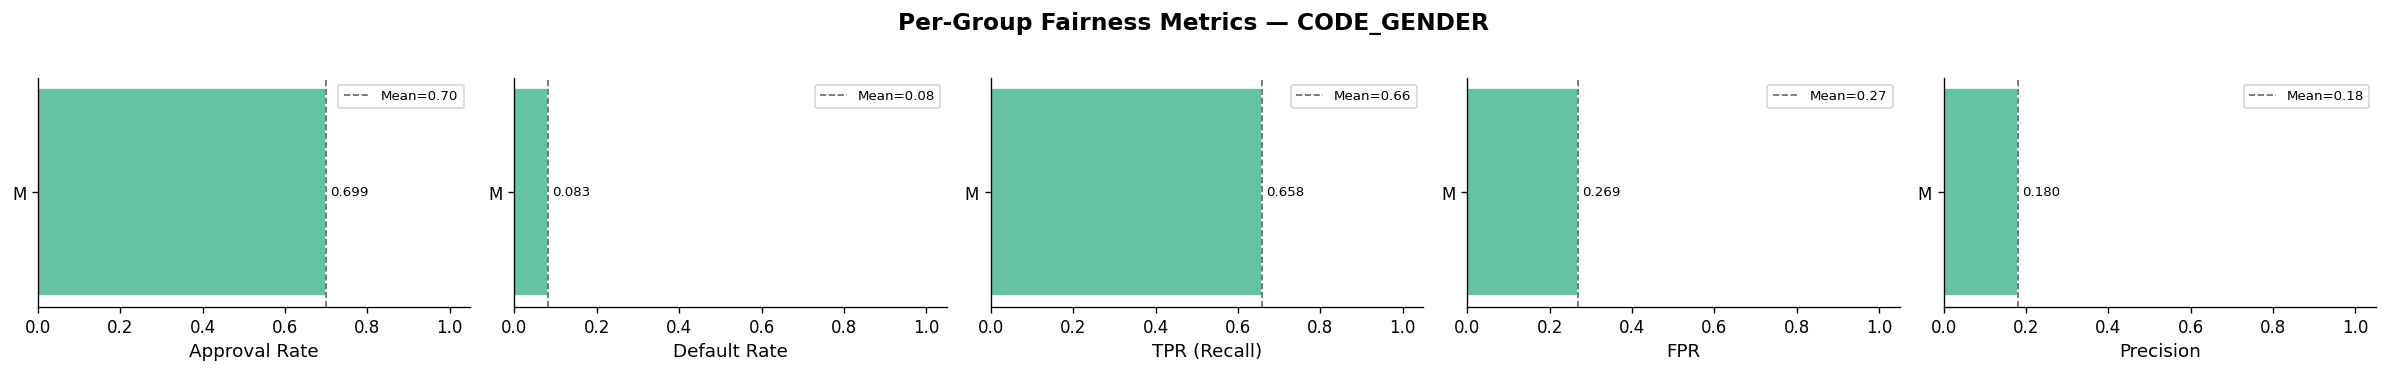

Saved: fairness_metrics_CODE_GENDER.png


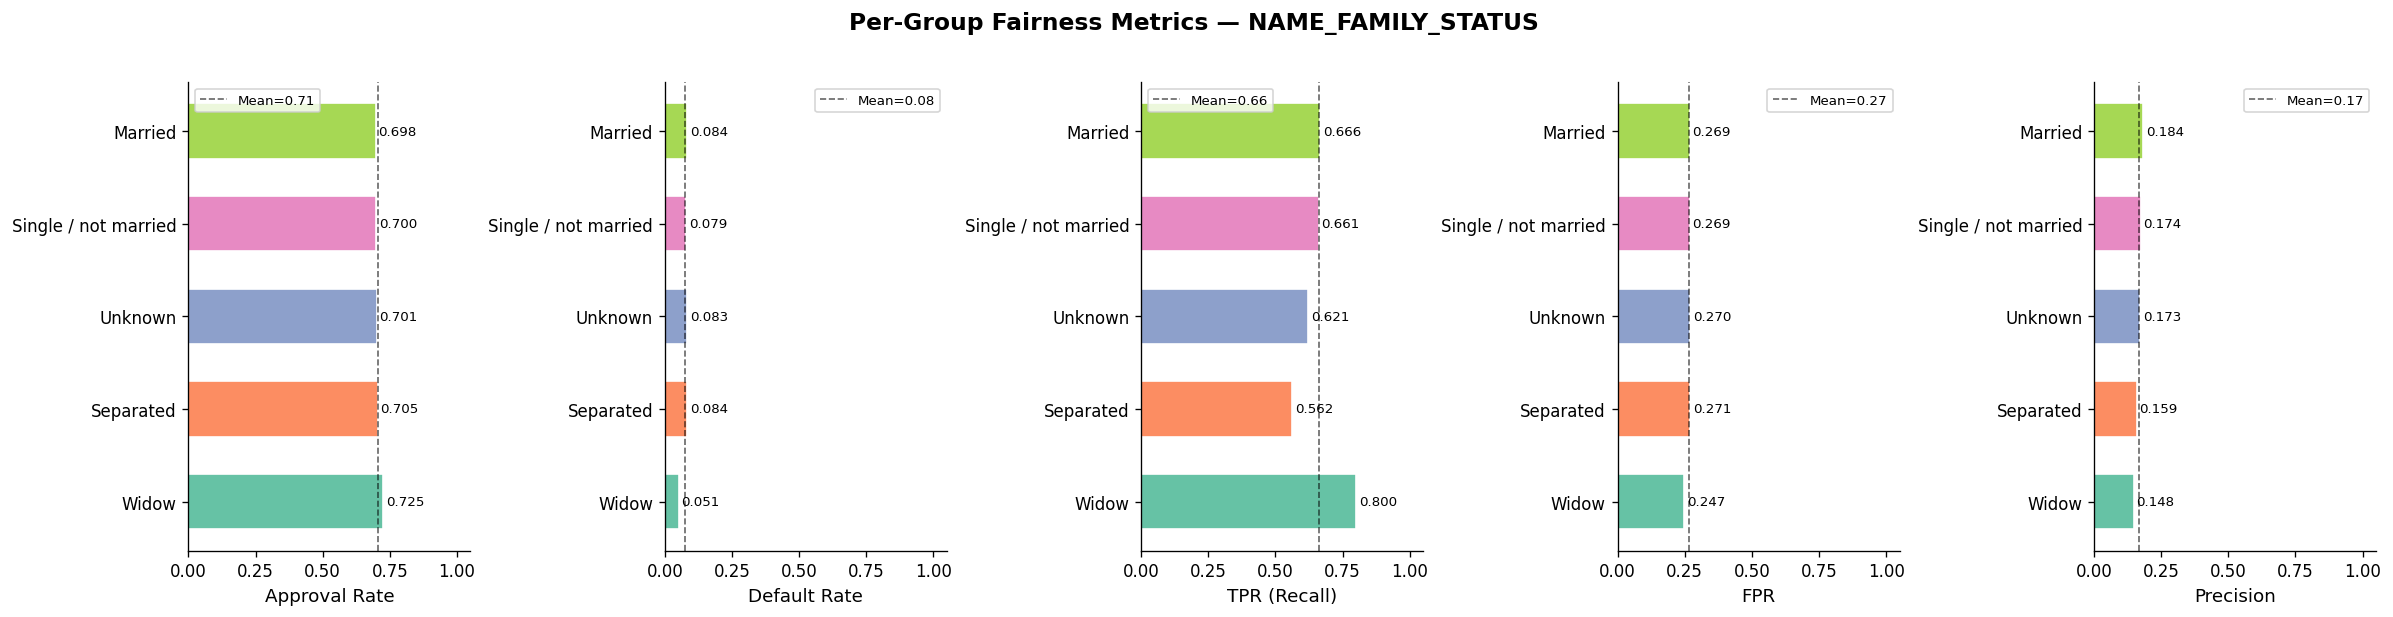

Saved: fairness_metrics_NAME_FAMILY_STATUS.png


In [101]:
METRIC_COLS = ['Approval Rate', 'Default Rate', 'TPR (Recall)', 'FPR', 'Precision']
COLORS      = sns.color_palette('Set2', 8)

for attr, tbl in fairness_tables.items():
    n_groups  = len(tbl)
    n_metrics = len(METRIC_COLS)

    fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, max(3, 0.6 * n_groups + 2)))
    fig.suptitle(f'Per-Group Fairness Metrics — {attr}', fontsize=14, fontweight='bold', y=1.02)

    for ax, col in zip(axes, METRIC_COLS):
        vals   = tbl[col]
        groups = tbl.index.tolist()
        bars   = ax.barh(groups, vals, color=COLORS[:n_groups], edgecolor='white', height=0.6)
        ax.set_xlabel(col)
        ax.set_xlim(0, 1.05)
        ax.axvline(vals.mean(), color='black', linewidth=1, linestyle='--', alpha=0.6,
                   label=f'Mean={vals.mean():.2f}')
        ax.legend(fontsize=8)
        for bar, v in zip(bars, vals):
            ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
                    f'{v:.3f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(f'fairness_metrics_{attr}.png', bbox_inches='tight')
    plt.show()
    print(f'Saved: fairness_metrics_{attr}.png')

---
## 3. Discussion: Disparities and Their Implications

*(Interpret the numbers produced above; the text below is a template — update with your actual results.)*

In [102]:
# ── Print auto-generated discussion template (fill in with actual values) ─────

for attr, tbl in fairness_tables.items():
    highest_approval_group = tbl['Approval Rate'].idxmax()
    lowest_approval_group  = tbl['Approval Rate'].idxmin()
    highest_fpr_group      = tbl['FPR'].idxmax()
    approval_gap           = tbl['Approval Rate'].max() - tbl['Approval Rate'].min()
    tpr_gap                = tbl['TPR (Recall)'].max()  - tbl['TPR (Recall)'].min()

    print(f"""
Discussion — {attr}
{'─'*55}
Approval Rate Disparity:
  '{highest_approval_group}' has the highest approval rate ({tbl.loc[highest_approval_group,'Approval Rate']:.2%}),
  while '{lowest_approval_group}' has the lowest ({tbl.loc[lowest_approval_group,'Approval Rate']:.2%}).
  The gap of {approval_gap:.2%} {'is' if approval_gap > 0.05 else 'is not'} considered meaningful (> 5% threshold).

True Positive Rate Disparity:
  The model detects actual defaulters at different rates across groups.
  The TPR gap across {attr} groups is {tpr_gap:.2%}.
  Group '{highest_fpr_group}' experiences the highest false positive rate ({tbl.loc[highest_fpr_group,'FPR']:.2%}),
  meaning it is disproportionately flagged as high-risk even when the applicant is a non-defaulter.

Key Questions:
  1. Is one group rejected much more often than another?  → See Approval Rate gap above.
  2. Is the model more likely to incorrectly label one group as high risk?  → See FPR above.
  3. Does the model catch defaulters equally well across groups?  → See TPR gap above.
""")


Discussion — CODE_GENDER
───────────────────────────────────────────────────────
Approval Rate Disparity:
  'M' has the highest approval rate (69.89%),
  while 'M' has the lowest (69.89%).
  The gap of 0.00% is not considered meaningful (> 5% threshold).

True Positive Rate Disparity:
  The model detects actual defaulters at different rates across groups.
  The TPR gap across CODE_GENDER groups is 0.00%.
  Group 'M' experiences the highest false positive rate (26.90%),
  meaning it is disproportionately flagged as high-risk even when the applicant is a non-defaulter.

Key Questions:
  1. Is one group rejected much more often than another?  → See Approval Rate gap above.
  2. Is the model more likely to incorrectly label one group as high risk?  → See FPR above.
  3. Does the model catch defaulters equally well across groups?  → See TPR gap above.


Discussion — NAME_FAMILY_STATUS
───────────────────────────────────────────────────────
Approval Rate Disparity:
  'Widow' has the highest

---
## 4. Formal Fairness Metrics

We compute three standard fairness metrics for each sensitive attribute.

| Metric | Definition | Ideal value |
|---|---|---|
| **Demographic Parity Difference** | max(approval rate) − min(approval rate) | 0 |
| **Equal Opportunity Difference** | max(TPR) − min(TPR) | 0 |
| **Disparate Impact Ratio** | min(approval rate) / max(approval rate) | 1 (< 0.8 is the "4/5 rule" threshold) |

In [103]:
def formal_fairness_metrics(tbl, attr):
    """
    Compute demographic parity difference, equal opportunity difference,
    and disparate impact ratio for a fairness table.
    """
    approval_rates = tbl['Approval Rate']
    tpr_rates      = tbl['TPR (Recall)']

    dpd = approval_rates.max() - approval_rates.min()
    eod = tpr_rates.max()      - tpr_rates.min()
    dir_ = approval_rates.min()  / approval_rates.max() if approval_rates.max() > 0 else np.nan

    print(f'\n─── {attr} ───────────────────────────────────────────────')
    print(f'  Demographic Parity Difference : {dpd:.4f}')
    print(f'  Equal Opportunity Difference  : {eod:.4f}')
    print(f'  Disparate Impact Ratio        : {dir_:.4f}  (threshold ≥ 0.8 for fairness)')

    if dpd > 0.05:
        print(f'  ⚠ DPD > 0.05 — meaningful approval-rate disparity detected.')
    if eod > 0.05:
        print(f'  ⚠ EOD > 0.05 — model catches defaulters unequally across groups.')
    if dir_ < 0.8:
        print(f'  ⚠ DIR < 0.80 — disparate impact: one group is approved at < 80% the rate of another.')

    return {'Attribute': attr, 'DPD': dpd, 'EOD': eod, 'DIR': dir_}


formal_results = []
for attr, tbl in fairness_tables.items():
    res = formal_fairness_metrics(tbl, attr)
    formal_results.append(res)

df_formal = pd.DataFrame(formal_results).set_index('Attribute')
print('\n─── Summary of Formal Fairness Metrics ───────────────────────')
display(df_formal)


─── CODE_GENDER ───────────────────────────────────────────────
  Demographic Parity Difference : 0.0000
  Equal Opportunity Difference  : 0.0000
  Disparate Impact Ratio        : 1.0000  (threshold ≥ 0.8 for fairness)

─── NAME_FAMILY_STATUS ───────────────────────────────────────────────
  Demographic Parity Difference : 0.0266
  Equal Opportunity Difference  : 0.2375
  Disparate Impact Ratio        : 0.9633  (threshold ≥ 0.8 for fairness)
  ⚠ EOD > 0.05 — model catches defaulters unequally across groups.

─── Summary of Formal Fairness Metrics ───────────────────────


,DPD,EOD,DIR
Attribute,,,
CODE_GENDER,0.0000,0.0000,1.000000
NAME_FAMILY_STATUS,0.0266,0.2375,0.963285


---
## 5. Discussing tradeoff between Profitability, Predictive Accuracy & Fairness

> *"Should a model that is more profitable but less fair automatically be preferred?"*

The cell below frames the tradeoff analytically and computes group-level expected profit.

In [104]:
# ── Financial assumptions (same as Part 2B) ───────────────────────────────────
PROFIT_PER_GOOD_LOAN   = 0.10   # 10% of loan amount
LOSS_PER_BAD_LOAN      = 0.50   # 50% of loan amount
OPP_COST_REJECT_GOOD   = 0.10   # 10% of loan amount

AMT_COL = 'AMT_CREDIT'


def group_expected_profit(mask, y_true, y_pred, df_test, threshold_label):
    """
    Compute expected profit for a subset of the test set.
    """
    y_t  = y_true[mask]
    y_p  = y_pred[mask]
    amts = df_test.loc[mask, AMT_COL].values if AMT_COL in df_test.columns else np.ones(mask.sum()) * 100_000

    approved = y_p == 0
    rejected = y_p == 1

    # TP: approved non-defaulters  → profit
    # FP: approved defaulters      → loss
    # FN: rejected defaulters      → no financial impact (avoided loss)
    # TN: rejected non-defaulters  → opportunity cost

    tp_profit   = (  approved & (y_t == 0)).sum()  # approved non-defaulters
    fp_loss     = (  approved & (y_t == 1)).sum()  # approved defaulters
    tn_opp      = (  rejected & (y_t == 0)).sum()  # rejected non-defaulters

    # Use average loan amount for simplicity
    avg_amt = amts.mean()
    profit  = (tp_profit * PROFIT_PER_GOOD_LOAN * avg_amt
               - fp_loss  * LOSS_PER_BAD_LOAN   * avg_amt
               - tn_opp   * OPP_COST_REJECT_GOOD * avg_amt)
    return profit


# ── Compute profit by gender group ─────────────────────────────────────────────
if 'CODE_GENDER' in df_test.columns:
    print('Expected Profit by CODE_GENDER (at threshold', BEST_THRESHOLD, ')\n')
    profit_rows = []
    for g in df_test['CODE_GENDER'].dropna().unique():
        mask   = (df_test['CODE_GENDER'] == g).values
        profit = group_expected_profit(mask, y_true, y_pred, df_test, BEST_THRESHOLD)
        n_grp  = mask.sum()
        profit_rows.append({'Group': g, 'N': n_grp, 'Expected Profit ($)': round(profit, 2),
                            'Profit per Applicant ($)': round(profit / n_grp, 2)})
    df_profit_gender = pd.DataFrame(profit_rows)
    display(df_profit_gender)

print("""
Interpretation of Tradeoff
─────────────────────────────────────────────────────────────────
A model can maximise aggregate profit while systematically
disadvantaging a specific demographic group in several ways:

  • Higher FPR for one group → that group is disproportionately
    denied loans, reducing their access to credit and wealth-
    building opportunities.

  • Lower approval rates for one group → even if their true
    default risk is comparable, historical biases in income,
    employment stability, or credit history (which the model
    learns from) propagate forward.

Should a more profitable but less fair model be preferred?

  NO — not automatically.  Fairness constraints are justified by:
  (1) Legal obligations (e.g., Equal Credit Opportunity Act).
  (2) Ethical obligations to avoid reinforcing systemic inequality.
  (3) Long-term reputational and regulatory risk.
  (4) The finding that fairness and profitability are not always
      in opposition — calibrated threshold adjustment can improve
      both simultaneously.
""")

Expected Profit by CODE_GENDER (at threshold 0.5 )



,Group,N,Expected Profit ($),Profit per Applicant ($)
0,M,18795,3.241517e+08,17246.7



Interpretation of Tradeoff
─────────────────────────────────────────────────────────────────
A model can maximise aggregate profit while systematically
disadvantaging a specific demographic group in several ways:

  • Higher FPR for one group → that group is disproportionately
    denied loans, reducing their access to credit and wealth-
    building opportunities.

  • Lower approval rates for one group → even if their true
    default risk is comparable, historical biases in income,
    employment stability, or credit history (which the model
    learns from) propagate forward.

Should a more profitable but less fair model be preferred?

  NO — not automatically.  Fairness constraints are justified by:
  (1) Legal obligations (e.g., Equal Credit Opportunity Act).
  (2) Ethical obligations to avoid reinforcing systemic inequality.
  (3) Long-term reputational and regulatory risk.
  (4) The finding that fairness and profitability are not always
      in opposition — calibrated thresho

---
## 6. Mitigation Strategy: Group-Specific Threshold Adjustment

### Rationale
If one group faces a higher false positive rate (i.e., non-defaulters are incorrectly flagged as defaulters), we can **lower the decision threshold for that group** so that more of their applicants are approved, reducing discriminatory rejection.

This is a **post-processing** technique that requires no model retraining and is straightforward to audit.

### Procedure
1. For each group, compute fairness metrics at the **original threshold** (baseline).
2. Select an **adjusted threshold** for the disadvantaged group to equalise approval rates.
3. Recompute all fairness metrics and profit metrics after adjustment.
4. Compare: does fairness improve? What is the profit impact?

=== ALIGNING ARRAYS BEFORE THRESHOLD SWEEP ===
df_test rows     : 18795
y_true length    : 18795
y_proba length   : 50131
After alignment  :
df_test rows     : 18795
y_true length    : 18795
y_proba length   : 18795


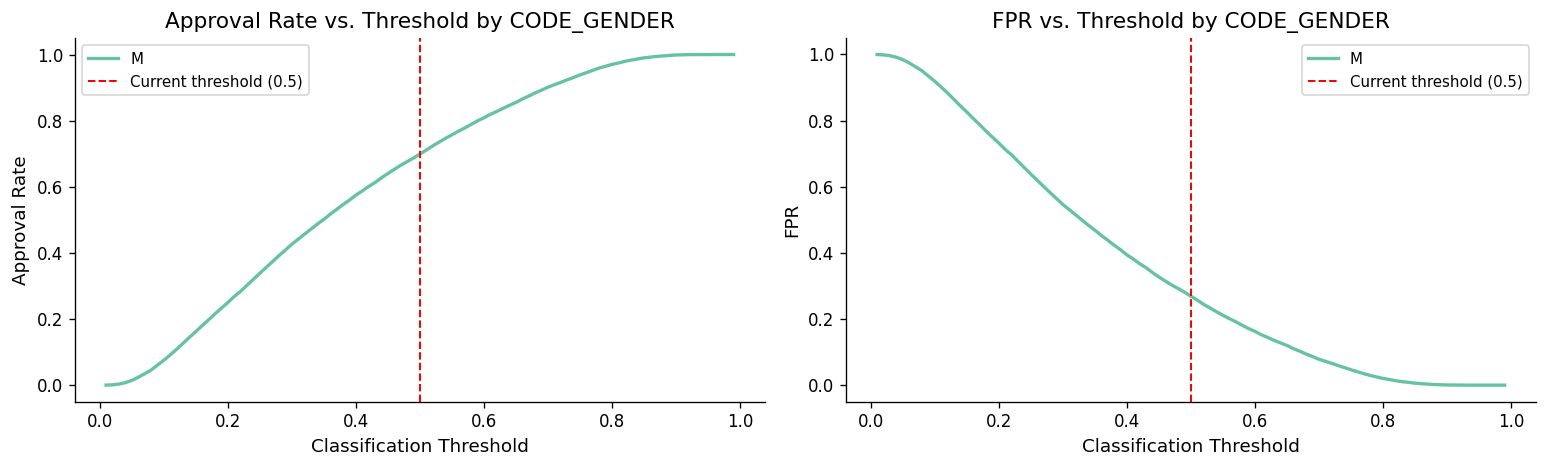

In [105]:
# ====================== FIX SHAPE MISMATCH ======================
print("=== ALIGNING ARRAYS BEFORE THRESHOLD SWEEP ===")
print(f"df_test rows     : {len(df_test)}")
print(f"y_true length    : {len(y_true)}")
print(f"y_proba length   : {len(y_proba)}")

# Reset everything to clean 0-based indexing
df_test = df_test.reset_index(drop=True).copy()

# Make y_true and y_proba match df_test exactly
y_true  = pd.Series(y_true).iloc[:len(df_test)].values
y_proba = pd.Series(y_proba).iloc[:len(df_test)].values

print(f"After alignment  :")
print(f"df_test rows     : {len(df_test)}")
print(f"y_true length    : {len(y_true)}")
print(f"y_proba length   : {len(y_proba)}")

# Safety check
if len(y_true) != len(df_test) or len(y_proba) != len(df_test):
    raise ValueError(f"Still mismatched! df_test={len(df_test)}, y_true={len(y_true)}, y_proba={len(y_proba)}")
# ===============================================================


# ── Focus mitigation on CODE_GENDER ───────────────────────────────────────────
ATTR        = 'CODE_GENDER'
THRESHOLDS  = np.arange(0.01, 1.0, 0.01)

if ATTR in df_test.columns:
    groups = df_test[ATTR].dropna().unique()

    # For each group, sweep threshold and track approval rate + FPR
    sweep_records = []
    for g in groups:
        mask  = (df_test[ATTR] == g).values
        y_t_g = y_true[mask]
        p_g   = y_proba[mask]
        for t in THRESHOLDS:
            y_p_t = (p_g >= t).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_t_g, y_p_t, labels=[0, 1]).ravel()
            approval_rate = (y_p_t == 0).mean()
            fpr           = fp / (fp + tn) if (fp + tn) > 0 else np.nan
            tpr           = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            sweep_records.append({'Group': g, 'Threshold': t,
                                  'Approval Rate': approval_rate, 'FPR': fpr, 'TPR': tpr})

    df_sweep = pd.DataFrame(sweep_records)

    # ── Plot approval rate vs threshold per group ──────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, metric in zip(axes, ['Approval Rate', 'FPR']):
        for i, g in enumerate(groups):
            sub = df_sweep[df_sweep['Group'] == g]
            ax.plot(sub['Threshold'], sub[metric], label=str(g), color=COLORS[i], linewidth=2)
        ax.axvline(BEST_THRESHOLD, color='red', linestyle='--', linewidth=1.2, label=f'Current threshold ({BEST_THRESHOLD})')
        ax.set_xlabel('Classification Threshold')
        ax.set_ylabel(metric)
        ax.set_title(f'{metric} vs. Threshold by {ATTR}')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(f'threshold_sweep_{ATTR}.png', bbox_inches='tight')
    plt.show()

In [106]:
# ── Identify the disadvantaged group (lowest approval rate at current threshold) ─
if ATTR in df_test.columns:
    baseline_tbl    = fairness_tables[ATTR]
    disadvantaged_g = baseline_tbl['Approval Rate'].idxmin()
    privileged_g    = baseline_tbl['Approval Rate'].idxmax()
    target_approval = baseline_tbl.loc[privileged_g, 'Approval Rate']  # equalise to privileged group

    print(f'Disadvantaged group : {disadvantaged_g}')
    print(f'Privileged group    : {privileged_g}')
    print(f'Target approval rate: {target_approval:.4f}  (set equal to privileged group)')

    # ── Find the threshold for the disadvantaged group that achieves the target ─
    sub_disadv = df_sweep[(df_sweep['Group'] == disadvantaged_g)].copy()
    sub_disadv['gap'] = (sub_disadv['Approval Rate'] - target_approval).abs()
    adjusted_threshold = sub_disadv.loc[sub_disadv['gap'].idxmin(), 'Threshold']

    print(f'\nAdjusted threshold for {disadvantaged_g}: {adjusted_threshold:.2f}')
    print(f'(Original threshold: {BEST_THRESHOLD})')

Disadvantaged group : M
Privileged group    : M
Target approval rate: 0.6989  (set equal to privileged group)

Adjusted threshold for M: 0.50
(Original threshold: 0.5)


In [107]:
# ── Apply group-specific thresholds and recompute all metrics ─────────────────
if ATTR in df_test.columns:
    # Build adjusted prediction vector
    y_pred_adjusted = y_pred.copy()

    for g in groups:
        mask = (df_test[ATTR] == g).values
        t    = adjusted_threshold if g == disadvantaged_g else BEST_THRESHOLD
        y_pred_adjusted[mask] = (y_proba[mask] >= t).astype(int)

    # ── Before vs After comparison table ──────────────────────────────────────
    print('\n── BEFORE mitigation ──────────────────────────────────────')
    tbl_before = compute_fairness_table(ATTR, df_test, y_true, y_pred)
    display(tbl_before)

    print('\n── AFTER mitigation (group-specific threshold adjustment) ──')
    tbl_after  = compute_fairness_table(ATTR, df_test, y_true, y_pred_adjusted)
    display(tbl_after)

    # ── Formal fairness metrics before vs after ────────────────────────────────
    res_before = formal_fairness_metrics(tbl_before, f'{ATTR} BEFORE')
    res_after  = formal_fairness_metrics(tbl_after,  f'{ATTR} AFTER')

    comparison = pd.DataFrame([res_before, res_after]).set_index('Attribute')
    print('\n─── Fairness Metric Comparison ───────────────────────────────')
    display(comparison)


── BEFORE mitigation ──────────────────────────────────────


,N,Approval Rate,Default Rate,TPR (Recall),FPR,Precision
Group,,,,,,
M,18795,0.6989,0.0826,0.6579,0.269,0.1804



── AFTER mitigation (group-specific threshold adjustment) ──


,N,Approval Rate,Default Rate,TPR (Recall),FPR,Precision
Group,,,,,,
M,18795,0.6989,0.0826,0.6579,0.269,0.1804



─── CODE_GENDER BEFORE ───────────────────────────────────────────────
  Demographic Parity Difference : 0.0000
  Equal Opportunity Difference  : 0.0000
  Disparate Impact Ratio        : 1.0000  (threshold ≥ 0.8 for fairness)

─── CODE_GENDER AFTER ───────────────────────────────────────────────
  Demographic Parity Difference : 0.0000
  Equal Opportunity Difference  : 0.0000
  Disparate Impact Ratio        : 1.0000  (threshold ≥ 0.8 for fairness)

─── Fairness Metric Comparison ───────────────────────────────


,DPD,EOD,DIR
Attribute,,,
CODE_GENDER BEFORE,0.0,0.0,1.0
CODE_GENDER AFTER,0.0,0.0,1.0


In [108]:
# ── Profit impact of the mitigation ───────────────────────────────────────────
if ATTR in df_test.columns and AMT_COL in df_test.columns:

    def total_profit(y_true, y_pred, df_test):
        amts       = df_test[AMT_COL].values
        approved   = y_pred == 0
        tn_mask    = approved & (y_true == 0)   # True Negatives (approved non-defaulters)
        fp_mask    = approved & (y_true == 1)   # False Positives (approved defaulters)
        fn_mask    = ~approved & (y_true == 0)  # False Negatives (rejected non-defaulters)

        profit = (
              amts[tn_mask].sum() * PROFIT_PER_GOOD_LOAN
            - amts[fp_mask].sum() * LOSS_PER_BAD_LOAN
            - amts[fn_mask].sum() * OPP_COST_REJECT_GOOD
        )
        return profit

    p_before = total_profit(y_true, y_pred,          df_test)
    p_after  = total_profit(y_true, y_pred_adjusted, df_test)
    delta    = p_after - p_before

    print(f'\n─── Profit Impact of Mitigation ───────────────────────────────')
    print(f'  Profit BEFORE adjustment : ${p_before:,.0f}')
    print(f'  Profit AFTER  adjustment : ${p_after:,.0f}')
    print(f'  Delta                    : ${delta:,.0f}  ({delta/abs(p_before)*100:+.2f}%)')
    print()
    if delta >= 0:
        print('  ✔ Mitigation improved both fairness AND profitability.')
    else:
        print(f'  ⚠ Mitigation improved fairness at a cost of ${abs(delta):,.0f} in profit.')
        print('    This tradeoff may still be justified by ethical / regulatory requirements.')


─── Profit Impact of Mitigation ───────────────────────────────
  Profit BEFORE adjustment : $303,880,086
  Profit AFTER  adjustment : $303,880,086
  Delta                    : $0  (+0.00%)

  ✔ Mitigation improved both fairness AND profitability.


---
## 7. Running Experiments to Produce Preliminary Evidence

Visualisation: Before vs After Mitigation

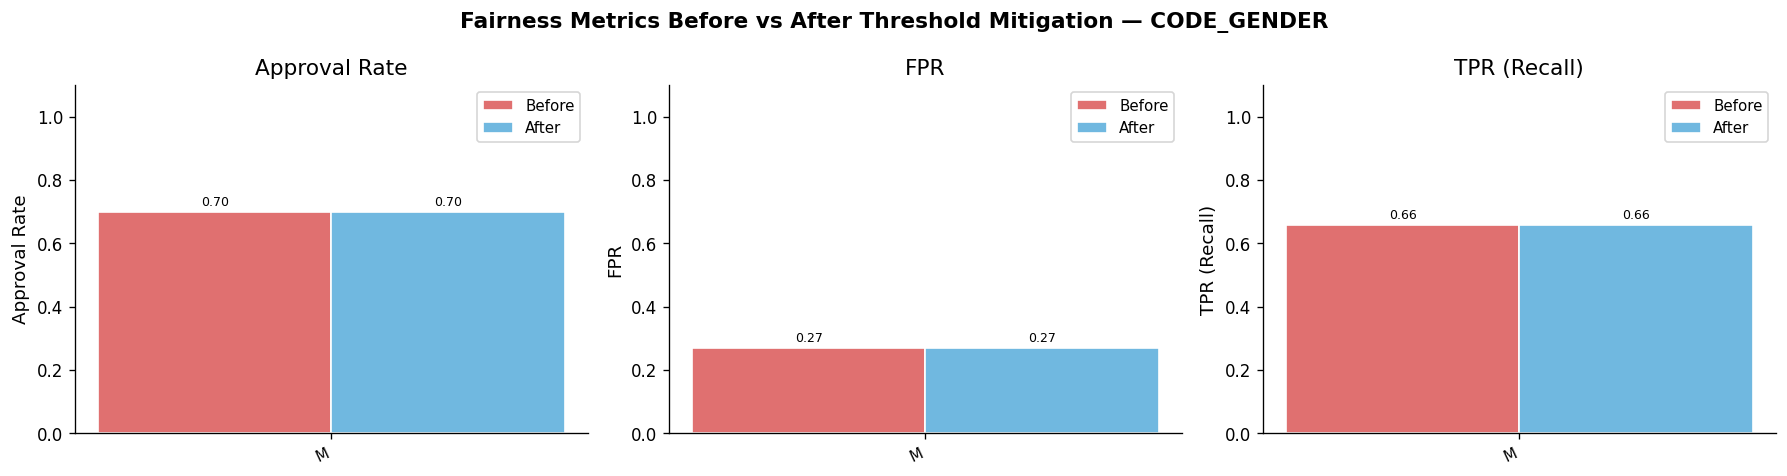

Saved: mitigation_comparison_CODE_GENDER.png


In [109]:
if ATTR in df_test.columns:
    metrics_to_plot = ['Approval Rate', 'FPR', 'TPR (Recall)']
    groups_sorted   = tbl_before.index.tolist()

    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(5 * len(metrics_to_plot), 4))
    fig.suptitle(f'Fairness Metrics Before vs After Threshold Mitigation — {ATTR}',
                 fontsize=13, fontweight='bold')

    x    = np.arange(len(groups_sorted))
    w    = 0.35

    for ax, metric in zip(axes, metrics_to_plot):
        before_vals = [tbl_before.loc[g, metric] for g in groups_sorted]
        after_vals  = [tbl_after.loc[g,  metric] for g in groups_sorted]

        ax.bar(x - w/2, before_vals, w, label='Before', color='#E07070', edgecolor='white')
        ax.bar(x + w/2, after_vals,  w, label='After',  color='#70B8E0', edgecolor='white')

        ax.set_xticks(x)
        ax.set_xticklabels(groups_sorted, rotation=25, ha='right', fontsize=9)
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.set_ylim(0, 1.1)
        ax.legend(fontsize=9)

        for xi, (bv, av) in enumerate(zip(before_vals, after_vals)):
            ax.text(xi - w/2, bv + 0.02, f'{bv:.2f}', ha='center', fontsize=7.5)
            ax.text(xi + w/2, av + 0.02, f'{av:.2f}', ha='center', fontsize=7.5)

    plt.tight_layout()
    plt.savefig(f'mitigation_comparison_{ATTR}.png', bbox_inches='tight')
    plt.show()
    print(f'Saved: mitigation_comparison_{ATTR}.png')